# Falcon 9 / BCHH Figure Generation Notebook

Refactored workflow for the BCHH seismo-acoustic figure set.

This notebook is organized so that timing assumptions are explicit and easy to change:

1. Define paths, video-derived source times, sensor distances, and environmental parameters.
2. Estimate still-air, wind-corrected, and shock-speed-corrected acoustic speeds.
3. Read/cache BCHH waveform data.
4. Remove instrument responses.
5. Prepare display streams using **ZEROPHASE** filters, so plotted energy is not moved before the physical onset.
6. Make the 30-minute overview figure.
7. Optionally load synchronized SpaceX/YouTube audio.
8. Make the 20-second zoom figure either in observed UTC time or reduced source time.

Important assumption: the BCHH seismic channels are interpreted here as **ground-coupled airwaves**, not direct seismic waves. Therefore, for timing reduction and predicted arrival annotations, `HH*` channels use the acoustic propagation speed unless `HH_USE_DIRECT_SEISMIC_SPEED=True`.

## 1. Imports


# NOTE: zerophase comparison version

This version is intentionally different from the original notebook. The important controls are in the setup cell:

```python
ZEROPHASE = False
RUN_ZEROPHASE_COMPARISON = True
ZEROPHASE_RUNS = [False, True]
```

When `RUN_ZEROPHASE_COMPARISON=True`, the zoom figure cells generate both causal and acausal-filtered versions, with filenames ending in `_zp_false` and `_zp_true`.


In [1]:
from pathlib import Path
import warnings
from pprint import pprint

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from obspy import read, Stream, Trace, UTCDateTime

# Optional: used for response inventories. If unavailable, response removal will fail
# with a clear message rather than silently producing uncorrected traces.
try:
    from flovopy.stationmetadata.build import NRL2inventory
except Exception as e:
    NRL2inventory = None
    warnings.warn(f"Could not import NRL2inventory from flovopy: {e}")

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 120,
})


## 2. User-editable configuration

Edit this cell when source-time picks, paths, sensor distances, or environmental assumptions change.

For video picks, use fractional frames explicitly. For example, if the explosion is visible on frame 2 but you infer onset between frames 1 and 2, use `frame=1.5`.


In [2]:
# -----------------------------------------------------------------------------
# Paths
# -----------------------------------------------------------------------------
MINISEED_DIR = Path('/Volumes/haldata/KSC/beforePASSCAL/EVENTS/20160901_SpaceXplosion')
OUTDIR = Path('/Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing_papers_reports')
OUTDIR.mkdir(parents=True, exist_ok=True)

RAW_CACHE = OUTDIR / 'phase1234_raw.mseed'
CORRECTED_CACHE = OUTDIR / 'phase1234_corrected.mseed'

AUDIO_FILE = Path('/Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/02_KSC/spaceX_explosion_movie/syncedsound2.mp3')


In [3]:

# -----------------------------------------------------------------------------
# Video-derived source times
# -----------------------------------------------------------------------------
FPS = 30.0
EVENT_DATE = '2016-09-01'

def utc_from_hms_frame(hh, mm, ss, frame, fps, date):
    """Convert HH:MM:SS + video frame number to UTCDateTime."""
    return UTCDateTime(f"{date}T{hh:02d}:{mm:02d}:{ss:02d}") + frame / fps

# Initial second-stage rupture: visible near frame 2; inferred onset between frames 1 and 2.
EXPLOSION_TIME = utc_from_hms_frame(13, 7, 12, frame=1.75, fps=FPS, date=EVENT_DATE)

# Update these frame picks as needed.
FIRST_STAGE = utc_from_hms_frame(13, 7, 15, frame=22.5, fps=FPS, date=EVENT_DATE)
CAPSULE = utc_from_hms_frame(13, 7, 24, frame=16, fps=FPS, date=EVENT_DATE)

# Initial second-stage rupture: visible near frame 2; inferred onset between frames 1 and 2.
EXPLOSION_TIME = UTCDateTime(2016, 9, 1, 13, 7, 12.08)

# Update these frame picks as needed.
precursor1 = UTCDateTime(2016, 9, 1, 13, 7, 15.283)
precursor2 = UTCDateTime(2016, 9, 1, 13, 7, 15.517)
FIRST_STAGE = UTCDateTime(2016, 9, 1, 13, 7, 15.75)
CAPSULE = UTCDateTime(2016, 9, 1, 13, 7, 24.6)

SOURCE_EVENTS = {
    "Second\nstage": EXPLOSION_TIME,
    "precursor1": precursor1,
    "precursor2": precursor2, 
    "First\nstage": FIRST_STAGE,
    "Capsule": CAPSULE,
}

# Use this to show uncertainty windows around video picks.
VIDEO_PICK_UNCERTAINTY_S = 1.0 / FPS


In [4]:
'''
# -----------------------------------------------------------------------------
# Cameras
# -----------------------------------------------------------------------------
camera_locations = {
    "youtube": {
        "name": "FIREY",
        "latitude": 28.5511389,
        "longitude": -80.6189278,
        "coordinate_source": "Coordinates supplied by video author, circa 2016",
    },

    "pad_nw": {
        "name": "PadNW",
        "latitude": 28.5626444,
        "longitude": -80.5778806,
        "coordinate_source": "Camera coordinates recorded in project KMZ",
    },

    "pad_west": {
        "name": "PadW",
        "latitude": 28.5621583,
        "longitude": -80.5785583,
        "coordinate_source": "Camera coordinates recorded in project KMZ",
    },

    "pad_ne": {
        "name": "PadNE",
        "latitude": 28.5623917,
        "longitude": -80.5767000,
        "coordinate_source": "Camera coordinates recorded in project KMZ",
    },

    "ucs3": {
        "name": "UCS-3",
        "latitude": 28.5751083,
        "longitude": -80.5736361,
        "coordinate_source": "Camera coordinates recorded in project KMZ",
    },

}



# -----------------------------------------------------------------------------
# BCHH sensor distances from SLC-40.
# -----------------------------------------------------------------------------
SENSOR_DISTANCES_M = {
    "HHE": 1421.8,
    "HHN": 1421.8,
    "HHZ": 1421.8,
    "HD1": 1442.2,
    "HD2": 1410.2,
    "HD3": 1414.8,
}

display(SENSOR_DISTANCES_M)
'''


'\n# -----------------------------------------------------------------------------\n# Cameras\n# -----------------------------------------------------------------------------\ncamera_locations = {\n    "youtube": {\n        "name": "FIREY",\n        "latitude": 28.5511389,\n        "longitude": -80.6189278,\n        "coordinate_source": "Coordinates supplied by video author, circa 2016",\n    },\n\n    "pad_nw": {\n        "name": "PadNW",\n        "latitude": 28.5626444,\n        "longitude": -80.5778806,\n        "coordinate_source": "Camera coordinates recorded in project KMZ",\n    },\n\n    "pad_west": {\n        "name": "PadW",\n        "latitude": 28.5621583,\n        "longitude": -80.5785583,\n        "coordinate_source": "Camera coordinates recorded in project KMZ",\n    },\n\n    "pad_ne": {\n        "name": "PadNE",\n        "latitude": 28.5623917,\n        "longitude": -80.5767000,\n        "coordinate_source": "Camera coordinates recorded in project KMZ",\n    },\n\n    "u

In [ ]:
from pathlib import Path

import pandas as pd
from obspy import UTCDateTime
from pyproj import Geod

from kml_utils import read_kml_points
from xml_utils import (
    inventory_channels_to_dataframe,
    load_inventory_for_time_range,
)


# -----------------------------------------------------------------------------
# Metadata files and event interval
# -----------------------------------------------------------------------------

KML_FILE = Path("launchpads_cameras.kml")
STATIONXML_FILE = Path("../03_stationxml/KSC.xml")

EVENT_START = UTCDateTime("2016-09-01T00:00:00")
EVENT_END = UTCDateTime("2016-09-02T00:00:00")

BCHH_NETWORK = "1R"
BCHH_STATION = "BCHH"
BCHH_LOCATION = "10"

GEOD = Geod(ellps="WGS84")


# -----------------------------------------------------------------------------
# Load fixed locations from KML
# -----------------------------------------------------------------------------

kml_locations = read_kml_points(KML_FILE)

SLC40 = kml_locations["SLC40"]
SLC41 = kml_locations["SLC41"]


# Map KML placemark names onto the short identifiers used in this notebook.
CAMERA_KML_NAMES = {
    "youtube": "YouTube Video",
    "pad_nw": "Pad NW",
    "pad_west": "Pad West",
    "pad_ne": "NE Tower",
    "ucs3": "UCS-3",
}

CAMERA_DISPLAY_NAMES = {
    "youtube": "FIREY",
    "pad_nw": "PadNW",
    "pad_west": "PadW",
    "pad_ne": "PadNE",
    "ucs3": "UCS-3",
}


def source_geometry(source, receiver):
    """Return source-to-receiver distance and forward azimuth."""
    azimuth_deg, _, distance_m = GEOD.inv(
        source["lon"],
        source["lat"],
        receiver["lon"],
        receiver["lat"],
    )

    return float(distance_m), float(azimuth_deg % 360.0)


camera_locations = {}

for camera_id, kml_name in CAMERA_KML_NAMES.items():
    point = kml_locations[kml_name]

    distance_m, azimuth_deg = source_geometry(
        source=SLC40,
        receiver=point,
    )

    camera_locations[camera_id] = {
        "name": CAMERA_DISPLAY_NAMES[camera_id],
        "latitude": float(point["lat"]),
        "longitude": float(point["lon"]),
        "altitude_m": point.get("altitude_m"),
        "distance_m": distance_m,
        "azimuth_deg": azimuth_deg,
        "coordinate_source": f"KML placemark: {kml_name}",
    }


camera_locations_df = (
    pd.DataFrame.from_dict(camera_locations, orient="index")
    .rename_axis("camera_id")
    .reset_index()
)

display(camera_locations_df)


# -----------------------------------------------------------------------------
# Load the BCHH channel positions from StationXML
# -----------------------------------------------------------------------------

inventory_event = load_inventory_for_time_range(
    stationxml_file=STATIONXML_FILE,
    starttime=EVENT_START,
    endtime=EVENT_END,
)

channels_df = inventory_channels_to_dataframe(inventory_event)

bchh_channels_df = channels_df.loc[
    (channels_df["network"] == BCHH_NETWORK)
    & (channels_df["station"] == BCHH_STATION)
    & (channels_df["location"] == BCHH_LOCATION)
].copy()


# The StationXML uses D* channel names, whereas the waveform files use
# HHE/HHN/HHZ and HD1/HD2/HD3.
XML_TO_WAVEFORM_CHANNEL = {
    "DHE": "HHE",
    "DHN": "HHN",
    "DHZ": "HHZ",
    "DD1": "HD1",
    "DD2": "HD2",
    "DD3": "HD3",
}

bchh_channels_df = bchh_channels_df.loc[
    bchh_channels_df["channel"].isin(XML_TO_WAVEFORM_CHANNEL)
].copy()

bchh_channels_df["waveform_channel"] = (
    bchh_channels_df["channel"].map(XML_TO_WAVEFORM_CHANNEL)
)

def calculate_row_geometry(row, source, geod):
    """Calculate source-to-receiver distance and ray azimuth."""
    ray_azimuth_deg, _, distance_m = geod.inv(
        source["lon"],
        source["lat"],
        float(row["longitude"]),
        float(row["latitude"]),
    )

    return pd.Series(
        {
            "distance_m": float(distance_m),
            "ray_azimuth_deg": float(ray_azimuth_deg % 360.0),
        }
    )

geometry_df = bchh_channels_df.apply(
    calculate_row_geometry,
    axis=1,
    source=SLC40,
)

bchh_channels_df = pd.concat(
    [
        bchh_channels_df.reset_index(drop=True),
        geometry_df.reset_index(drop=True),
    ],
    axis=1,
)

display(
    bchh_channels_df[
        [
            "seed_id",
            "channel",
            "waveform_channel",
            "latitude",
            "longitude",
            "distance_m",
            "azimuth_deg",
        ]
    ]
)

# -----------------------------------------------------------------------------
# Distances used by waveform plotting and travel-time calculations
# -----------------------------------------------------------------------------

SENSOR_DISTANCES_M = (
    bchh_channels_df
    .set_index("waveform_channel")["distance_m"]
    .to_dict()
)

display(SENSOR_DISTANCES_M)

,camera_id,name,latitude,longitude,altitude_m,distance_m,azimuth_deg,coordinate_source
0,youtube,FIREY,28.551140,-80.618930,8.0,4254.532067,253.676701,KML placemark: YouTube Video
1,pad_nw,PadNW,28.562646,-80.577882,14.0,102.864227,319.923729,KML placemark: Pad NW
2,pad_west,PadW,28.562160,-80.578559,22.0,134.745638,280.624512,KML placemark: Pad West
3,pad_ne,PadNE,28.562393,-80.576702,73.0,70.670423,44.172628,KML placemark: NE Tower
4,ucs3,UCS-3,28.575108,-80.573638,0.0,1501.050255,13.445065,KML placemark: UCS-3


,seed_id,channel,waveform_channel,latitude,longitude,distance_m,azimuth_deg,azimuth_deg
0,1R.BCHH.10.DD1,DD1,HD1,28.574222,-80.572417,1439.963831,0.0,18.985737
1,1R.BCHH.10.DD2,DD2,HD2,28.573881,-80.572296,1408.338457,90.0,19.940904
2,1R.BCHH.10.DD3,DD3,HD3,28.574006,-80.572560,1412.854330,0.0,18.761692
3,1R.BCHH.10.DHE,DHE,HHE,28.574017,-80.572376,1419.886511,90.0,19.435717
4,1R.BCHH.10.DHN,DHN,HHN,28.574017,-80.572376,1419.886511,0.0,19.435717
5,1R.BCHH.10.DHZ,DHZ,HHZ,28.574017,-80.572376,1419.886511,0.0,19.435717


{'HD1': 1439.9638305217552,
 'HD2': 1408.3384566901343,
 'HD3': 1412.8543304792386,
 'HHE': 1419.88651062152,
 'HHN': 1419.88651062152,
 'HHZ': 1419.88651062152}

In [6]:

CHANNEL_ORDER = ["HD1", "HD2", "HD3", "HHE", "HHN", "HHZ"]

# Since the observed seismic energy is interpreted as ground-coupled airwave,
# HH channels use the acoustic speed by default for reduction/annotations.
#HH_USE_DIRECT_SEISMIC_SPEED = False
#DIRECT_SEISMIC_SPEED_MPS = 1100.0

# -----------------------------------------------------------------------------
# Environmental/acoustic assumptions
# -----------------------------------------------------------------------------
RelativeHumidityPercent = 89.5 #92
TemperatureF = 80.65 #80
WindDirectionFromDeg = 144 #150
WindDirectionDeg = (WindDirectionFromDeg + 180) % 360  # direction wind blows TOWARD
WindSpeedKnots = 5.5 #10
WindSpeedMps = WindSpeedKnots * 0.514444
RAY_AZIMUTH_DEG = 19.0  # SLC40 -> BCHH bearing
REFERENCE_DISTANCE_M = SENSOR_DISTANCES_M['HHZ']
REFERENCE_OVERPRESSURE_PA = 1400.0
# new values come from 

# -----------------------------------------------------------------------------
# Figure windows and phase annotations
# -----------------------------------------------------------------------------
PRE_EVENT_SEC = 180
POST_EVENT_SEC = 1800
PLOT_START = EXPLOSION_TIME - 150
PLOT_END = EXPLOSION_TIME + POST_EVENT_SEC

PHASES = [
    ("Phase I", EXPLOSION_TIME, EXPLOSION_TIME + 70),
    ("Phase II", UTCDateTime('2016-09-01T13:14:15'), UTCDateTime('2016-09-01T13:15:45')),
    ("Phase III", UTCDateTime('2016-09-01T13:19:12'), UTCDateTime('2016-09-01T13:25:00')),
    ("Phase IV", UTCDateTime('2016-09-01T13:29:54'), UTCDateTime('2016-09-01T13:34:54')),
]

TREMOR_START = UTCDateTime("2016-09-01T13:08:48")
TREMOR_END = UTCDateTime("2016-09-01T13:12:00")

# -----------------------------------------------------------------------------
# Filtering - causal or acausal
# -----------------------------------------------------------------------------
# Interactive/default value used by single-run cells.
ZEROPHASE = False

# Batch comparison: set True to save one full set of figures for each value.
# Filenames will include `_zp_false` or `_zp_true` before the extension.
RUN_ZEROPHASE_COMPARISON = True
ZEROPHASE_RUNS = [False, True]



In [7]:

# -----------------------------------------------------------------------------
# Video-derived source times
# -----------------------------------------------------------------------------
FPS = 30.0
EVENT_DATE = '2016-09-01'

def utc_from_hms_frame(hh, mm, ss, frame, fps, date):
    """Convert HH:MM:SS + video frame number to UTCDateTime."""
    return UTCDateTime(f"{date}T{hh:02d}:{mm:02d}:{ss:02d}") + frame / fps

# Initial second-stage rupture: visible near frame 2; inferred onset between frames 1 and 2.
EXPLOSION_TIME = utc_from_hms_frame(13, 7, 12, frame=1.75, fps=FPS, date=EVENT_DATE)

# Update these frame picks as needed.
FIRST_STAGE = utc_from_hms_frame(13, 7, 15, frame=22.5, fps=FPS, date=EVENT_DATE)
CAPSULE = utc_from_hms_frame(13, 7, 24, frame=16, fps=FPS, date=EVENT_DATE)

# Initial second-stage rupture: visible near frame 2; inferred onset between frames 1 and 2.
EXPLOSION_TIME = UTCDateTime(2016, 9, 1, 13, 7, 12.08)

# Update these frame picks as needed.
precursor1 = UTCDateTime(2016, 9, 1, 13, 7, 15.283)
precursor2 = UTCDateTime(2016, 9, 1, 13, 7, 15.517)
FIRST_STAGE = UTCDateTime(2016, 9, 1, 13, 7, 15.75)
CAPSULE = UTCDateTime(2016, 9, 1, 13, 7, 24.6)

SOURCE_EVENTS = {
    "Second\nstage": EXPLOSION_TIME,
    "precursor1": precursor1,
    "precursor2": precursor2, 
    "First\nstage": FIRST_STAGE,
    "Capsule": CAPSULE,
}

# Use this to show uncertainty windows around video picks.
VIDEO_PICK_UNCERTAINTY_S = 1.0 / FPS


## 3. Estimate acoustic speeds

This cell prints the still-air speed, simple shock-speed estimate, wind projection, and combined effective speed. `ACOUSTIC_SPEED_MPS` is the value used by later timing-reduction cells.


In [9]:
from physics import effective_sound_speed_along_ray, compute_speed_of_sound, mach_vs_overpressure, fahrenheit_to_celsius
print("Using physics functions from local physics.py")

'''
speed_of_sound = float(compute_speed_of_sound(
    fahrenheit_to_celsius(TemperatureF),
    relative_humidity=RelativeHumidityPercent,
))

print(
    f"(no wind) Speed of sound at {TemperatureF} F and "
    f"{RelativeHumidityPercent}% RH: {speed_of_sound:.1f} m/s"
)

results = mach_vs_overpressure(
    reference_distance=REFERENCE_DISTANCE_M,
    reference_overpressure=REFERENCE_OVERPRESSURE_PA,
    speed_of_sound=speed_of_sound,
)

print(
    f"At array: Mach = {results['mach_at_array']:.3f}, "
    f"speed = {results['speed_at_array']:.1f} m/s"
)

print(
    f"Along raypath: Mean Mach = {results['mean_mach']:.3f}, "
    f"speed = {results['mean_speed']:.1f} m/s"
)
'''

acoustic_result_bchh = effective_sound_speed_along_ray(
    TemperatureF,
    relative_humidity_percent=RelativeHumidityPercent,
    wind_direction_from_deg=WindDirectionFromDeg,
    wind_speed_knots=WindSpeedKnots,
    ray_azimuth_deg=RAY_AZIMUTH_DEG,
    reference_distance=REFERENCE_DISTANCE_M,
    reference_overpressure=REFERENCE_OVERPRESSURE_PA,
)

pprint(acoustic_result_bchh)

ACOUSTIC_SPEED_MPS = acoustic_result_bchh['speed_of_sound_still_air_mps']
WIND_SPEED_MPS = acoustic_result_bchh['wind_speed_mps']
SHOCK_SPEED_MPS = acoustic_result_bchh['effective_sound_speed_mps']-WIND_SPEED_MPS


acoustic_result_fire = effective_sound_speed_along_ray(
    TemperatureF,
    relative_humidity_percent=RelativeHumidityPercent,
    wind_direction_from_deg=WindDirectionFromDeg,
    wind_speed_knots=WindSpeedKnots,
    ray_azimuth_deg=RAY_AZIMUTH_DEG,
    reference_distance=REFERENCE_DISTANCE_M,
    reference_overpressure=REFERENCE_OVERPRESSURE_PA,
)

Using physics functions from local physics.py
358.6682022227768
****
Still-air sound speed: 348.8 m/s, Still-air shock speed: 358.7 m/s, wind along ray: 1.6 m/s, effective sound speed: 360.3 m/s
{'effective_sound_speed_mps': np.float64(360.2911034819988),
 'ray_azimuth_deg': 19.0,
 'speed_of_sound_still_air_mps': np.float64(348.80653333333333),
 'wind_along_ray_mps': np.float64(1.6229012592219765),
 'wind_direction_to_deg': 324.0,
 'wind_speed_mps': 2.8294420000000002}
358.6682022227768
****
Still-air sound speed: 348.8 m/s, Still-air shock speed: 358.7 m/s, wind along ray: 1.6 m/s, effective sound speed: 360.3 m/s


In [ ]:
def add_acoustic_propagation_columns(
    dataframe,
    *,
    temperature_f,
    relative_humidity_percent,
    wind_direction_from_deg,
    wind_speed_knots,
    reference_overpressure_pa,
    distance_column="distance_m",
    azimuth_column="azimuth_deg",
):
    """
    Calculate atmospheric propagation parameters for every receiver row.

    Each row uses its own source-to-receiver azimuth and distance.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Must contain distance and azimuth columns.
    temperature_f : float
        Air temperature in degrees Fahrenheit.
    relative_humidity_percent : float
        Relative humidity in percent.
    wind_direction_from_deg : float
        Meteorological wind direction: direction from which wind blows.
    wind_speed_knots : float
        Wind speed in knots.
    reference_overpressure_pa : float
        Reference overpressure passed to
        ``effective_sound_speed_along_ray``.
    distance_column : str
        Column containing source-to-receiver distance in metres.
    azimuth_column : str
        Column containing forward source-to-receiver azimuth in degrees.

    Returns
    -------
    pandas.DataFrame
        Copy of the input table with atmospheric propagation columns added.
    """
    required_columns = {
        distance_column,
        azimuth_column,
    }

    missing_columns = required_columns.difference(dataframe.columns)

    if missing_columns:
        raise KeyError(
            f"Missing required columns: {sorted(missing_columns)}"
        )

    result = dataframe.copy()

    acoustic_rows = []

    for row in result.itertuples(index=False):
        distance_m = float(getattr(row, distance_column))
        azimuth_deg = float(getattr(row, azimuth_column))

        acoustic_result = effective_sound_speed_along_ray(
            temperature_f,
            relative_humidity_percent=relative_humidity_percent,
            wind_direction_from_deg=wind_direction_from_deg,
            wind_speed_knots=wind_speed_knots,
            ray_azimuth_deg=azimuth_deg,
            reference_distance=distance_m,
            reference_overpressure=reference_overpressure_pa,
        )

        effective_speed_mps = float(
            acoustic_result["effective_sound_speed_mps"]
        )

        acoustic_rows.append(
            {
                "acoustic_travel_time_s": (
                    distance_m / float(acoustic_result["acoustic_speed_with_wind_mps"])
                ),
                "shockwave_travel_time_s": (
                    distance_m / effective_speed_mps
                ),                
                "effective_sound_speed_mps": effective_speed_mps,
                "still_air_sound_speed_mps": float(
                    acoustic_result[
                        "speed_of_sound_still_air_mps"
                    ]
                ),
                "shockwave_speed_mps": float(['shockwave_speed_mps'])
                "wind_along_ray_mps": float(
                    acoustic_result["wind_along_ray_mps"]
                ),
                "wind_direction_to_deg": float(
                    acoustic_result["wind_direction_to_deg"]
                ),
                "wind_speed_mps": float(
                    acoustic_result["wind_speed_mps"]
                ),
            }
        )

    acoustic_df = pd.DataFrame(
        acoustic_rows,
        index=result.index,
    )

    return pd.concat(
        [result, acoustic_df],
        axis=1,
    )

camera_locations_df = add_acoustic_propagation_columns(
    dataframe=camera_locations_df,
    temperature_f=TemperatureF,
    relative_humidity_percent=RelativeHumidityPercent,
    wind_direction_from_deg=WindDirectionFromDeg,
    wind_speed_knots=WindSpeedKnots,
    reference_overpressure_pa=REFERENCE_OVERPRESSURE_PA,
)

display(
    camera_locations_df[
        [
            "camera_id",
            "name",
            "latitude",
            "longitude",
            "distance_m",
            "azimuth_deg",
            "effective_sound_speed_mps",
            "acoustic_travel_time_s",
            "wind_along_ray_mps",
        ]
    ]
)

bchh_channels_df = add_acoustic_propagation_columns(
    dataframe=bchh_channels_df,
    temperature_f=TemperatureF,
    relative_humidity_percent=RelativeHumidityPercent,
    wind_direction_from_deg=WindDirectionFromDeg,
    wind_speed_knots=WindSpeedKnots,
    reference_overpressure_pa=REFERENCE_OVERPRESSURE_PA,
    distance_column="distance_m",
    azimuth_column="ray_azimuth_deg",
)

display(
    bchh_channels_df[
        [
            "seed_id",
            "channel",
            "waveform_channel",
            "latitude",
            "longitude",
            "distance_m",
            "azimuth_deg",
            "effective_sound_speed_mps",
            "acoustic_travel_time_s",
            "wind_along_ray_mps",
        ]
    ]
)

SENSOR_DISTANCES_M = (
    bchh_channels_df
    .set_index("waveform_channel")["distance_m"]
    .to_dict()
)

SENSOR_ACOUSTIC_TRAVEL_TIMES_S = (
    bchh_channels_df
    .set_index("waveform_channel")["acoustic_travel_time_s"]
    .to_dict()
)

CAMERA_DISTANCES_M = (
    camera_locations_df
    .set_index("camera_id")["distance_m"]
    .to_dict()
)

CAMERA_ACOUSTIC_TRAVEL_TIMES_S = (
    camera_locations_df
    .set_index("camera_id")["acoustic_travel_time_s"]
    .to_dict()
)

print("BCHH distances:")
display(SENSOR_DISTANCES_M)

print("BCHH acoustic travel times:")
display(SENSOR_ACOUSTIC_TRAVEL_TIMES_S)

print("Camera distances:")
display(CAMERA_DISTANCES_M)

print("Camera acoustic travel times:")
display(CAMERA_ACOUSTIC_TRAVEL_TIMES_S)

360.14475064141175
****
Still-air sound speed: 348.8 m/s, Still-air shock speed: 360.1 m/s, wind along ray: 1.0 m/s, effective sound speed: 361.1 m/s
354.2098834363448
****
Still-air sound speed: 348.8 m/s, Still-air shock speed: 354.2 m/s, wind along ray: 2.8 m/s, effective sound speed: 357.0 m/s
354.66895691537667
****
Still-air sound speed: 348.8 m/s, Still-air shock speed: 354.7 m/s, wind along ray: 2.1 m/s, effective sound speed: 356.7 m/s
353.5753941897661
****
Still-air sound speed: 348.8 m/s, Still-air shock speed: 353.6 m/s, wind along ray: 0.5 m/s, effective sound speed: 354.1 m/s
358.74752931426775
****
Still-air sound speed: 348.8 m/s, Still-air shock speed: 358.7 m/s, wind along ray: 1.8 m/s, effective sound speed: 360.6 m/s


,camera_id,name,latitude,longitude,distance_m,azimuth_deg,effective_sound_speed_mps,acoustic_travel_time_s,wind_along_ray_mps
0,youtube,FIREY,28.551140,-80.618930,4254.532067,253.676701,361.097459,11.782227,0.952708
1,pad_nw,PadNW,28.562646,-80.577882,102.864227,319.923729,357.032168,0.288109,2.822284
2,pad_west,PadW,28.562160,-80.578559,134.745638,280.624512,356.725589,0.377729,2.056632
3,pad_ne,PadNE,28.562393,-80.576702,70.670423,44.172628,354.058324,0.199601,0.482930
4,ucs3,UCS-3,28.575108,-80.573638,1501.050255,13.445065,360.587167,4.162794,1.839638


358.6898532300533
****
Still-air sound speed: 348.8 m/s, Still-air shock speed: 358.7 m/s, wind along ray: 2.3 m/s, effective sound speed: 361.0 m/s
358.6527908236659
****
Still-air sound speed: 348.8 m/s, Still-air shock speed: 358.7 m/s, wind along ray: -1.7 m/s, effective sound speed: 357.0 m/s
358.66050441783136
****
Still-air sound speed: 348.8 m/s, Still-air shock speed: 358.7 m/s, wind along ray: 2.3 m/s, effective sound speed: 360.9 m/s
358.6682022227768
****
Still-air sound speed: 348.8 m/s, Still-air shock speed: 358.7 m/s, wind along ray: -1.7 m/s, effective sound speed: 357.0 m/s
358.6682022227768
****
Still-air sound speed: 348.8 m/s, Still-air shock speed: 358.7 m/s, wind along ray: 2.3 m/s, effective sound speed: 361.0 m/s
358.6682022227768
****
Still-air sound speed: 348.8 m/s, Still-air shock speed: 358.7 m/s, wind along ray: 2.3 m/s, effective sound speed: 361.0 m/s


,seed_id,channel,waveform_channel,latitude,longitude,distance_m,azimuth_deg,azimuth_deg,effective_sound_speed_mps,acoustic_travel_time_s,wind_along_ray_mps
0,1R.BCHH.10.DD1,DD1,HD1,28.574222,-80.572417,1439.963831,0.0,18.985737,360.978920,3.989052,2.289067
1,1R.BCHH.10.DD2,DD2,HD2,28.573881,-80.572296,1408.338457,90.0,19.940904,356.989687,3.945040,-1.663104
2,1R.BCHH.10.DD3,DD3,HD3,28.574006,-80.572560,1412.854330,0.0,18.761692,360.949571,3.914271,2.289067
3,1R.BCHH.10.DHE,DHE,HHE,28.574017,-80.572376,1419.886511,90.0,19.435717,357.005098,3.977216,-1.663104
4,1R.BCHH.10.DHN,DHN,HHN,28.574017,-80.572376,1419.886511,0.0,19.435717,360.957269,3.933669,2.289067
5,1R.BCHH.10.DHZ,DHZ,HHZ,28.574017,-80.572376,1419.886511,0.0,19.435717,360.957269,3.933669,2.289067


BCHH distances:


...

{'HD1': 3.9890524104564715,
 'HD2': 3.945039618160365,
 'HD3': 3.9142707006137853,
 'HHE': 3.9772163445362927,
 'HHN': 3.9336692539980866,
 'HHZ': 3.9336692539980866}

Camera distances:


{'youtube': 4254.532067218973,
 'pad_nw': 102.86422721215838,
 'pad_west': 134.7456384340701,
 'pad_ne': 70.67042317377076,
 'ucs3': 1501.050254805887}

Camera acoustic travel times:


{'youtube': 11.782226552736306,
 'pad_nw': 0.2881091298863416,
 'pad_west': 0.37772910738557497,
 'pad_ne': 0.19960107805176197,
 'ucs3': 4.162794443191256}

## 4. Waveform I/O

The raw stream is cached after trimming to avoid repeatedly reading the full day files.


In [ ]:
def read_bchh_stream(
    miniseed_dir: Path,
    cache_file: Path,
    starttime: UTCDateTime,
    endtime: UTCDateTime,
    overwrite_cache: bool = False,
) -> Stream:
    """Read BCHH miniSEED files and cache the trimmed/merged stream."""
    if cache_file.exists() and not overwrite_cache:
        st = read(str(cache_file))
        return st.trim(starttime, endtime, pad=False)

    st = Stream()

    # Original day-file convention used in the current working directory.
    files = sorted(miniseed_dir.glob('*.20160901T000000'))

    # Fallbacks for normal miniSEED suffixes.
    if not files:
        files = sorted(miniseed_dir.glob('*.mseed')) + sorted(miniseed_dir.glob('*.msd'))

    if not files:
        raise FileNotFoundError(f'No miniSEED files found in {miniseed_dir}')

    for fn in files:
        st += read(str(fn))

    st.trim(starttime, endtime)
    st.merge(method=1, fill_value='interpolate')
    st.write(str(cache_file), format='MSEED')
    return st


st_raw = read_bchh_stream(
    MINISEED_DIR,
    RAW_CACHE,
    EXPLOSION_TIME - PRE_EVENT_SEC,
    EXPLOSION_TIME + POST_EVENT_SEC,
)
st_raw.sort(keys=['station', 'channel'])
print(st_raw)
for tr in st_raw:
    print(tr.id, tr.stats.starttime, tr.stats.endtime, tr.stats.sampling_rate, tr.stats.npts)


6 Trace(s) in Stream:
FL.BCHH.00.HD1 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.064000Z | 250.0 Hz, 494997 samples
FL.BCHH.00.HD2 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.064000Z | 250.0 Hz, 494997 samples
FL.BCHH.00.HD3 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.064000Z | 250.0 Hz, 494997 samples
FL.BCHH.00.HHE | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.064000Z | 250.0 Hz, 494997 samples
FL.BCHH.00.HHN | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.064000Z | 250.0 Hz, 494997 samples
FL.BCHH.00.HHZ | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.064000Z | 250.0 Hz, 494997 samples
FL.BCHH.00.HD1 2016-09-01T13:04:12.080000Z 2016-09-01T13:37:12.064000Z 250.0 494997
FL.BCHH.00.HD2 2016-09-01T13:04:12.080000Z 2016-09-01T13:37:12.064000Z 250.0 494997
FL.BCHH.00.HD3 2016-09-01T13:04:12.080000Z 2016-09-01T13:37:12.064000Z 250.0 494997
FL.BCHH.00.HHE 2016-09-01T13:04:12.080000Z 2016-09-01T13:37:12.064000Z 250.0 494997
FL.BCHH.00.HHN 2016-09-01T13:0

## 5. Instrument response removal

This follows the same general pattern as the Artemis 2 response-correction workflow:

- `HH*` channels: Centaur + Trillium/TCP response, output as ground velocity.
- `HD*` channels: Centaur + infraBSU response, output as pressure.

If the corrected cache already exists, it is read directly.


In [ ]:
def is_seismic_channel(channel: str) -> bool:
    ch = channel.upper()
    return ch[1] in ['HL']


def is_infrasound_channel(channel: str) -> bool:
    ch = channel.upper()
    return ch[1] == 'D'

def is_audio_channel(channel: str) -> bool:
    return channel.upper() in {'AUD', 'AUDIO'}


def build_centaur_inventory_for_trace(tr, sensor: str, vpp: float, units=None):
    """Build a minimal response inventory for one Centaur-recorded trace."""
    if NRL2inventory is None:
        raise ImportError('NRL2inventory is unavailable. Install/import flovopy or provide StationXML.')

    return NRL2inventory(
        nrl_path=None,
        net=tr.stats.network,
        sta=tr.stats.station,
        loc=tr.stats.location,
        chans=[tr.stats.channel],
        datalogger='Centaur',
        sensor=sensor,
        Vpp=vpp,
        fsamp=tr.stats.sampling_rate,
        lat=0.0,
        lon=0.0,
        elev=0.0,
        depth=0.0,
        sitename='',
        ondate=tr.stats.starttime,
        offdate=tr.stats.endtime,
        sensitivity=None,
        units=units,
    )


def remove_bchh_response(
    st: Stream,
    seismic_sensor: str = 'TCP',
    seismic_vpp: float = 40.0,
    infra_sensor: str = 'infrabsu',
    infra_vpp: float = 1.0,
    infra_extra_factor: float | None = None,
    water_level: float | None = None,
) -> Stream:
    """Return a response-corrected copy of the BCHH stream."""
    out = Stream()

    for tr0 in st:
        tr = tr0.copy()
        ch = tr.stats.channel.upper()

        tr.detrend('demean')
        tr.detrend('linear')
        tr.taper(max_percentage=0.01)

        if is_seismic_channel(ch):
            inv = build_centaur_inventory_for_trace(
                tr,
                sensor=seismic_sensor,
                vpp=seismic_vpp,
                units='m/s',
            )
            tr.remove_response(
                inventory=inv,
                output='VEL',
                water_level=water_level,
                pre_filt=None,
                zero_mean=False,
                taper=False,
            )
            tr.stats.units = 'm/s'

        elif is_infrasound_channel(ch):
            inv = build_centaur_inventory_for_trace(
                tr,
                sensor=infra_sensor,
                vpp=infra_vpp,
                units='Pa',
            )
            tr.remove_response(
                inventory=inv,
                output='DEF',
                water_level=water_level,
                pre_filt=None,
                zero_mean=False,
                taper=False,
            )
            if infra_extra_factor is not None:
                tr.data = tr.data * infra_extra_factor
            tr.stats.units = 'Pa'

        else:
            warnings.warn(f'Skipping response removal for unrecognized channel {tr.id}')

        out += tr

    return out


if CORRECTED_CACHE.exists():
    st_corr = read(str(CORRECTED_CACHE))
else:
    st_corr = remove_bchh_response(st_raw)
    st_corr.write(str(CORRECTED_CACHE), format='MSEED')

st_corr.sort(keys=['station', 'channel'])
print(st_corr)


6 Trace(s) in Stream:
FL.BCHH.00.HD1 | 2016-09-01T13:04:12.068000Z - 2016-09-01T13:37:12.064000Z | 250.0 Hz, 495000 samples
FL.BCHH.00.HD2 | 2016-09-01T13:04:12.068000Z - 2016-09-01T13:37:12.064000Z | 250.0 Hz, 495000 samples
FL.BCHH.00.HD3 | 2016-09-01T13:04:12.068000Z - 2016-09-01T13:37:12.064000Z | 250.0 Hz, 495000 samples
FL.BCHH.00.HHE | 2016-09-01T13:04:12.068000Z - 2016-09-01T13:37:12.064000Z | 250.0 Hz, 495000 samples
FL.BCHH.00.HHN | 2016-09-01T13:04:12.068000Z - 2016-09-01T13:37:12.064000Z | 250.0 Hz, 495000 samples
FL.BCHH.00.HHZ | 2016-09-01T13:04:12.068000Z - 2016-09-01T13:37:12.064000Z | 250.0 Hz, 495000 samples


## 6. Generic plotting and preprocessing utilities

ZEROPHASE filters can still introduce phase/group delay, so pick timing should be checked against minimally processed traces as well.


In [ ]:
def trace_time_array_datetime64(tr):
    """Return matplotlib date numbers for all samples in a trace."""
    t0 = tr.stats.starttime.datetime
    sr = float(tr.stats.sampling_rate)
    seconds = np.arange(tr.stats.npts, dtype=float) / sr
    return mdates.date2num(t0) + seconds / 86400.0


def robust_scale(data, percentile=99.3):
    """Robust absolute-amplitude scale for display."""
    x = np.asarray(data, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return 1.0
    s = np.percentile(np.abs(x), percentile)
    return s if np.isfinite(s) and s > 0 else 1.0


def select_channels_in_order(st: Stream, channel_order) -> Stream:
    """Return a stream containing the first matching trace for each requested channel."""
    selected = Stream()
    for ch in channel_order:
        matches = st.select(channel=ch)
        if len(matches) == 0:
            matches = Stream([tr for tr in st if tr.stats.channel.upper() == ch.upper()])
        if len(matches):
            selected += matches[0].copy()
        else:
            warnings.warn(f'No trace found for channel {ch}')
    return selected


def preprocess_display_stream(
    st: Stream,
    starttime: UTCDateTime | None = None,
    endtime: UTCDateTime | None = None,
    infra_filter: dict | None = None,
    seis_filter: dict | None = None,
) -> Stream:
    """Trim, detrend, taper, and filter a stream for display only."""
    out = Stream()
    for tr0 in st:
        tr = tr0.copy()
        if starttime is not None and endtime is not None:
            tr.trim(starttime, endtime, pad=True, fill_value=0.0)
        tr.detrend('demean')
        tr.detrend('linear')
        tr.taper(max_percentage=0.005)

        ch = tr.stats.channel.upper()
        if is_infrasound_channel(ch) and infra_filter is not None:
            tr.filter(**infra_filter)
        elif is_seismic_channel(ch) and seis_filter is not None:
            tr.filter(**seis_filter)

        out += tr
    return out


def acoustic_or_seismic_delay_s(
    channel: str,
    distance_m: float,
    acoustic_speed_mps: float,
    direct_seismic_speed_mps: float,
    hh_use_direct_seismic_speed: bool,
) -> float:
    """Return the travel-time correction for one physical BCHH channel."""
    ch = channel.upper()
    if is_audio_channel(ch):
        return 0.0
    if is_infrasound_channel(ch):
        return distance_m / acoustic_speed_mps
    if is_seismic_channel(ch):
        speed = direct_seismic_speed_mps if hh_use_direct_seismic_speed else acoustic_speed_mps
        return distance_m / speed
    return 0.0


def reduce_stream_to_source_time_physical(
    st: Stream,
    sensor_distances_m: dict,
    acoustic_speed_mps: float,
    direct_seismic_speed_mps: float,
    hh_use_direct_seismic_speed: bool,
    audio_delay_s: float,
) -> Stream:
    """Shift each trace earlier by its assumed source-to-receiver travel time."""
    st_red = st.copy()

    for tr in st_red:
        ch = tr.stats.channel.upper()

        if is_audio_channel(ch):
            delay_s = audio_delay_s
        elif ch in sensor_distances_m:
            delay_s = acoustic_or_seismic_delay_s(
                ch,
                distance_m=sensor_distances_m[ch],
                acoustic_speed_mps=acoustic_speed_mps,
                direct_seismic_speed_mps=direct_seismic_speed_mps,
                hh_use_direct_seismic_speed=hh_use_direct_seismic_speed,
            )
        else:
            delay_s = 0.0

        print(f"Reducing {tr.id} by {delay_s:.4f} s")
        tr.stats.starttime -= delay_s
        tr.stats.processing = tr.stats.get("processing", [])
        tr.stats.processing.append(f"reduced_time_shift_minus_{delay_s:.4f}_s")

    return st_red


def zerophase_tag(zerophase: bool) -> str:
    """Short filename tag for the filter phase convention."""
    return "zp_true" if bool(zerophase) else "zp_false"


def add_zerophase_tag(outfile_base: Path, zerophase: bool) -> Path:
    """Append the zerophase convention to an output filename stem."""
    return outfile_base.with_name(f"{outfile_base.name}_{zerophase_tag(zerophase)}")


def bandpass_filter_dict(freqmin, freqmax, corners=4, zerophase=False):
    """Build an ObsPy bandpass filter dictionary with explicit zerophase."""
    return {
        "type": "bandpass",
        "freqmin": float(freqmin),
        "freqmax": float(freqmax),
        "corners": int(corners),
        "zerophase": bool(zerophase),
    }


## 7. Build the response-corrected display stream


In [ ]:
def build_overview_stream(
    st: Stream,
    plot_start: UTCDateTime,
    plot_end: UTCDateTime,
    zerophase: bool,
    infra_freqmin: float = 0.5,
    infra_freqmax: float = 25.0,
    seis_freqmin: float = 0.5,
    seis_freqmax: float = 25.0,
    corners: int = 4,
) -> Stream:
    """Build the filtered 30-minute display stream for one zerophase setting."""
    overview_infra_filter = bandpass_filter_dict(
        freqmin=infra_freqmin,
        freqmax=infra_freqmax,
        corners=corners,
        zerophase=zerophase,
    )
    overview_seis_filter = bandpass_filter_dict(
        freqmin=seis_freqmin,
        freqmax=seis_freqmax,
        corners=corners,
        zerophase=zerophase,
    )

    return preprocess_display_stream(
        st,
        starttime=plot_start,
        endtime=plot_end,
        infra_filter=overview_infra_filter,
        seis_filter=overview_seis_filter,
    )


st_ordered = select_channels_in_order(st_corr, CHANNEL_ORDER)
st_overview = build_overview_stream(
    st=st_ordered,
    plot_start=PLOT_START,
    plot_end=PLOT_END,
    zerophase=ZEROPHASE,
)

print(f"Overview stream built with ZEROPHASE={ZEROPHASE}")
print(st_overview)


Overview stream built with ZEROPHASE=False
6 Trace(s) in Stream:
FL.BCHH.00.HD1 | 2016-09-01T13:04:42.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 487501 samples
FL.BCHH.00.HD2 | 2016-09-01T13:04:42.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 487501 samples
FL.BCHH.00.HD3 | 2016-09-01T13:04:42.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 487501 samples
FL.BCHH.00.HHE | 2016-09-01T13:04:42.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 487501 samples
FL.BCHH.00.HHN | 2016-09-01T13:04:42.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 487501 samples
FL.BCHH.00.HHZ | 2016-09-01T13:04:42.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 487501 samples


## 8. 30-minute overview figure


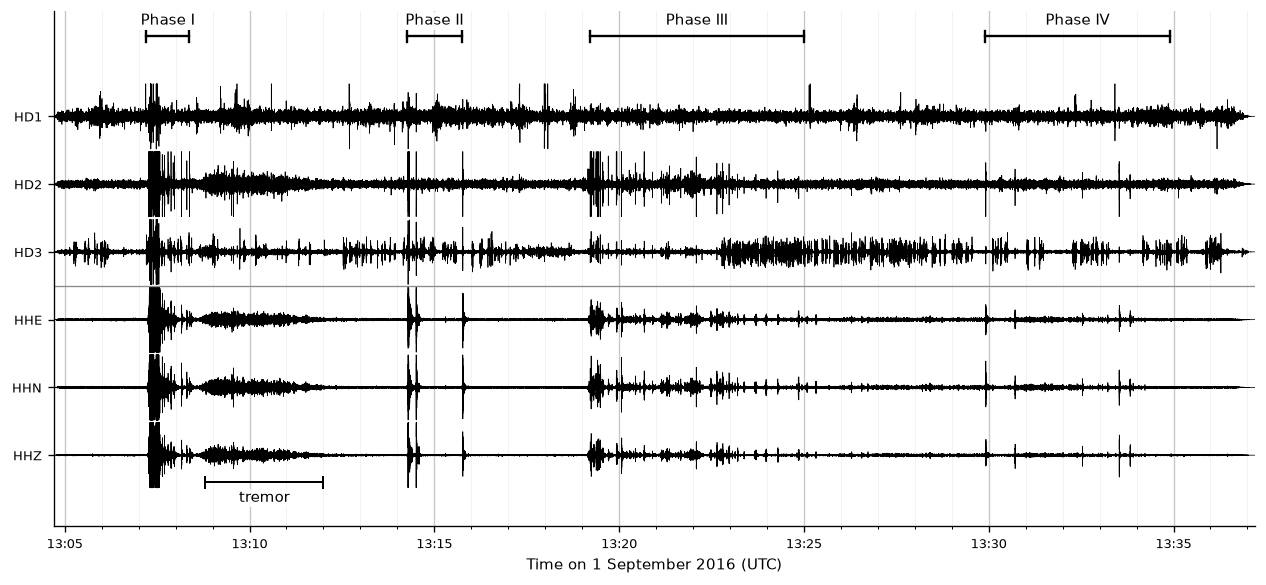

In [ ]:
def add_time_bar(ax, t0, t1, y, text, above=True, lw=1.4, fontsize=9):
    """Draw a bracket-style time interval annotation."""
    x0 = mdates.date2num(t0.datetime)
    x1 = mdates.date2num(t1.datetime)

    ax.plot([x0, x1], [y, y], color="black", lw=lw, clip_on=False, zorder=20)
    tick = 0.08
    ax.plot([x0, x0], [y - tick, y + tick], color="black", lw=lw, clip_on=False, zorder=20)
    ax.plot([x1, x1], [y - tick, y + tick], color="black", lw=lw, clip_on=False, zorder=20)

    dy = 0.12 if above else -0.12
    va = "bottom" if above else "top"
    ax.text(
        (x0 + x1) / 2,
        y + dy,
        text,
        ha="center",
        va=va,
        fontsize=fontsize,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1.0),
        clip_on=False,
        zorder=25,
    )


def make_overview_figure(
    st: Stream,
    outfile_base: Path,
    plot_start: UTCDateTime,
    plot_end: UTCDateTime,
    phases: list,
    explosion_time: UTCDateTime,
    tremor_start: UTCDateTime | None = None,
    tremor_end: UTCDateTime | None = None,
    normalize_by_group: bool = False,
    clip: float = 3.0,
    trace_gain: float = 0.15,
):
    """Make the 30-minute BCHH overview figure."""
    n = len(st)
    if n == 0:
        raise ValueError("No traces to plot")

    fig, ax = plt.subplots(figsize=(11.0, 5.8))
    offsets = np.arange(n)[::-1].astype(float)
    channel_labels = []

    infra_scales = [robust_scale(tr.data) for tr in st if is_infrasound_channel(tr.stats.channel)]
    seis_scales = [robust_scale(tr.data) for tr in st if is_seismic_channel(tr.stats.channel)]
    group_scale_infra = np.median(infra_scales) if infra_scales else 1.0
    group_scale_seis = np.median(seis_scales) if seis_scales else 1.0

    for i, tr in enumerate(st):
        y0 = offsets[i]
        ch = tr.stats.channel.upper()
        t = trace_time_array_datetime64(tr)
        data = np.nan_to_num(tr.data.astype(float), nan=0.0, posinf=0.0, neginf=0.0)

        if normalize_by_group:
            scale = group_scale_infra if is_infrasound_channel(ch) else group_scale_seis
        else:
            scale = robust_scale(data, percentile=99.3)

        y = y0 + np.clip(data / scale, -clip, clip) * trace_gain
        ax.plot(t, y, '-', color='black', lw=0.45, rasterized=True)
        channel_labels.append(ch)

    ax.set_yticks(offsets)
    ax.set_yticklabels(channel_labels)
    ax.set_ylim(-1.05, n + 0.55)
    ax.set_xlim(mdates.date2num(plot_start.datetime), mdates.date2num(plot_end.datetime))

    ax.xaxis.set_major_locator(mdates.MinuteLocator(byminute=range(0, 60, 5)))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=1))
    ax.grid(axis='x', which='major', color='0.78', lw=0.8)
    ax.grid(axis='x', which='minor', color='0.93', lw=0.4)
    ax.set_xlabel('Time on 1 September 2016 (UTC)')

    # Separator between infrasound and seismic channels for default 3+3 order.
    if n >= 6:
        ax.axhline(2.5, color='0.55', lw=0.8)

    phase_y = n + 0.18
    for name, t0, t1 in phases:
        if name.strip().lower() == 'phase i':
            t0 = explosion_time
        if t1 < plot_start or t0 > plot_end:
            continue
        add_time_bar(ax, max(t0, plot_start), min(t1, plot_end), phase_y, name, above=True)

    if tremor_start is not None and tremor_end is not None:
        if tremor_end >= plot_start and tremor_start <= plot_end:
            add_time_bar(
                ax,
                max(tremor_start, plot_start),
                min(tremor_end, plot_end),
                y=-0.4,
                text='tremor',
                above=False,
                lw=1.2,
            )

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    fig.subplots_adjust(left=0.08, right=0.99, top=0.88, bottom=0.14)

    for ext in ['png', 'pdf']:
        fig.savefig(outfile_base.with_suffix(f'.{ext}'), dpi=300, bbox_inches='tight', pad_inches=0.04)

    return fig, ax


overview_outfile = add_zerophase_tag(
    OUTDIR / 'fig03_bchh_30min_overview',
    ZEROPHASE,
)

fig, ax = make_overview_figure(
    st_overview,
    overview_outfile,
    PLOT_START,
    PLOT_END,
    phases=PHASES,
    explosion_time=EXPLOSION_TIME,
    tremor_start=TREMOR_START,
    tremor_end=TREMOR_END,
    normalize_by_group=False,
    clip=3.0,
    trace_gain=0.16,
)
plt.show()


## 9. Quick amplitude diagnostic

Use this to sanity-check response-corrected amplitudes before using the figures in the manuscript.


In [ ]:
rows = []
for tr in st_ordered:
    x = np.asarray(tr.data, dtype=float)
    rows.append({
        'id': tr.id,
        'channel': tr.stats.channel,
        'units': getattr(tr.stats, 'units', ''),
        'sampling_rate': tr.stats.sampling_rate,
        'min': float(np.nanmin(x)),
        'max': float(np.nanmax(x)),
        'p99_abs': float(np.nanpercentile(np.abs(x), 99)),
        'p99_9_abs': float(np.nanpercentile(np.abs(x), 99.9)),
    })

try:
    import pandas as pd
    display(pd.DataFrame(rows))
except Exception:
    for r in rows:
        print(r)


,id,channel,units,sampling_rate,min,max,p99_abs,p99_9_abs
0,FL.BCHH.00.HD1,HD1,,250.0,-0.145826,0.598798,0.112567,0.184508
1,FL.BCHH.00.HD2,HD2,,250.0,-0.007892,0.059309,0.003544,0.005126
2,FL.BCHH.00.HD3,HD3,,250.0,-0.115557,0.803731,0.028911,0.053913
3,FL.BCHH.00.HHE,HHE,,250.0,-0.001092,0.001003,0.000033,0.000187
4,FL.BCHH.00.HHN,HHN,,250.0,-0.002212,0.001889,0.000043,0.000295
5,FL.BCHH.00.HHZ,HHZ,,250.0,-0.002833,0.002176,0.000057,0.000476


## 10. Load synchronized video/audio track

The audio track is treated as an approximate source-time reference, not an independent calibrated acoustic sensor. If `librosa` or the MP3 file is unavailable, the rest of the notebook still works without audio.


In [ ]:
def load_video_audio_as_stream(audio_file: Path, starttime: UTCDateTime, network='YT', station='SYNC', channel='AUD') -> Stream:
    """Load an MP3/WAV file as a single ObsPy trace."""
    try:
        import librosa
    except Exception as e:
        raise ImportError('librosa is required to load MP3 audio') from e

    y, sr = librosa.load(audio_file, sr=None)
    tr = Trace(data=np.asarray(y, dtype=np.float32))
    tr.stats.sampling_rate = sr
    tr.stats.network = network
    tr.stats.station = station
    tr.stats.location = ''
    tr.stats.channel = channel
    tr.stats.starttime = starttime
    return Stream([tr])


def prepare_audio_for_plot(
    st_audio: Stream,
    zoom_start: UTCDateTime | None = None,
    zoom_end: UTCDateTime | None = None,
    freqmin: float | None = None,
    freqmax: float | None = None,
    audio_time_shift_s: float | None = None,
    demean: bool = True,
    normalize: bool = True,
    zerophase: bool = False,
    corners: int = 4,
) -> Stream:
    """Prepare video audio for display using explicitly supplied filter parameters."""
    sta = st_audio.copy()
    for tr in sta:
        if demean:
            tr.detrend('demean')
        if freqmin is not None and freqmax is not None:
            tr.filter(
                'bandpass',
                freqmin=freqmin,
                freqmax=freqmax,
                corners=corners,
                zerophase=bool(zerophase),
            )
        if audio_time_shift_s is not None:
            tr.stats.starttime += audio_time_shift_s
        if zoom_start is not None and zoom_end is not None:
            tr.trim(zoom_start, zoom_end, pad=False)
        if normalize:
            tr.normalize()
    return sta


AUDIO_STARTTIME = UTCDateTime('2016-09-01T13:07:10.000')  # edit if resynchronized

st_audio_raw = load_video_audio_as_stream(
    audio_file=AUDIO_FILE,
    starttime=AUDIO_STARTTIME,
)


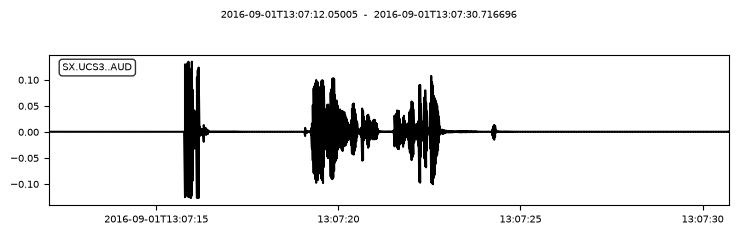

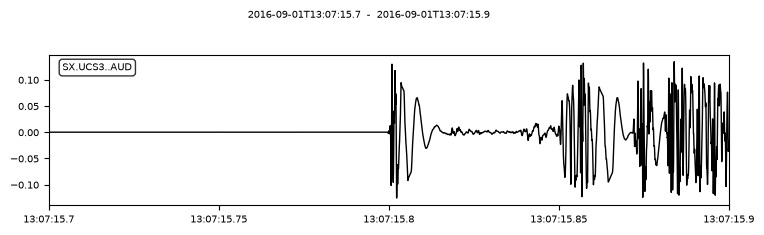

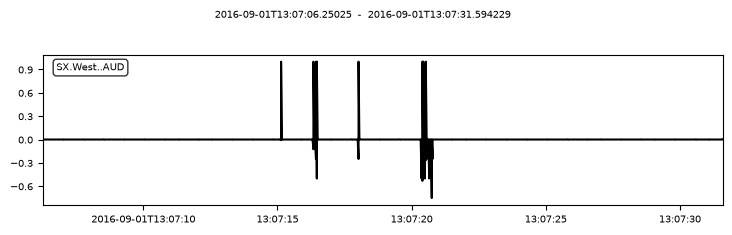

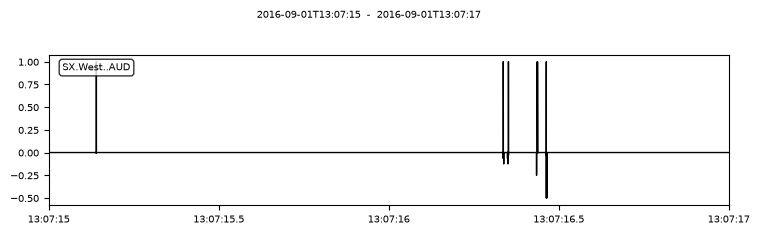

In [ ]:
# Load other audio
UCS3_FILE = AUDIO_FILE.parent / 'camera_UCS3_audio.wav'
uc3_video_start = UTCDateTime("2016-09-01T13:07:12.05005")
st_ucs3_raw = load_video_audio_as_stream(UCS3_FILE, starttime=uc3_video_start, network='SX', station='UCS3', channel='AUD')
st_ucs3_raw.plot();
st_ucs3_raw.plot(starttime=UTCDateTime(2016,9,1,13,7,15.7), endtime=UTCDateTime(2016,9,1,13,7,15.9));

WESTFIXED_FILE = AUDIO_FILE.parent / 'camera_WestFixed_audio.wav'
wf_video_start = UTCDateTime("2016-09-01T13:07:06.25025")
st_wf_raw = load_video_audio_as_stream(WESTFIXED_FILE, starttime=wf_video_start, network='SX', station='West', channel='AUD')
st_wf_raw.plot();
st_wf_raw.plot(starttime=UTCDateTime(2016,9,1,13,7,15), endtime=UTCDateTime(2016,9,1,13,7,17));



6 Trace(s) in Stream:
FL.BCHH.00.HD1 | 2016-09-01T13:04:12.068000Z - 2016-09-01T13:37:12.064000Z | 250.0 Hz, 495000 samples
FL.BCHH.00.HD2 | 2016-09-01T13:04:12.068000Z - 2016-09-01T13:37:12.064000Z | 250.0 Hz, 495000 samples
FL.BCHH.00.HD3 | 2016-09-01T13:04:12.068000Z - 2016-09-01T13:37:12.064000Z | 250.0 Hz, 495000 samples
FL.BCHH.00.HHE | 2016-09-01T13:04:12.068000Z - 2016-09-01T13:37:12.064000Z | 250.0 Hz, 495000 samples
FL.BCHH.00.HHN | 2016-09-01T13:04:12.068000Z - 2016-09-01T13:37:12.064000Z | 250.0 Hz, 495000 samples
FL.BCHH.00.HHZ | 2016-09-01T13:04:12.068000Z - 2016-09-01T13:37:12.064000Z | 250.0 Hz, 495000 samples


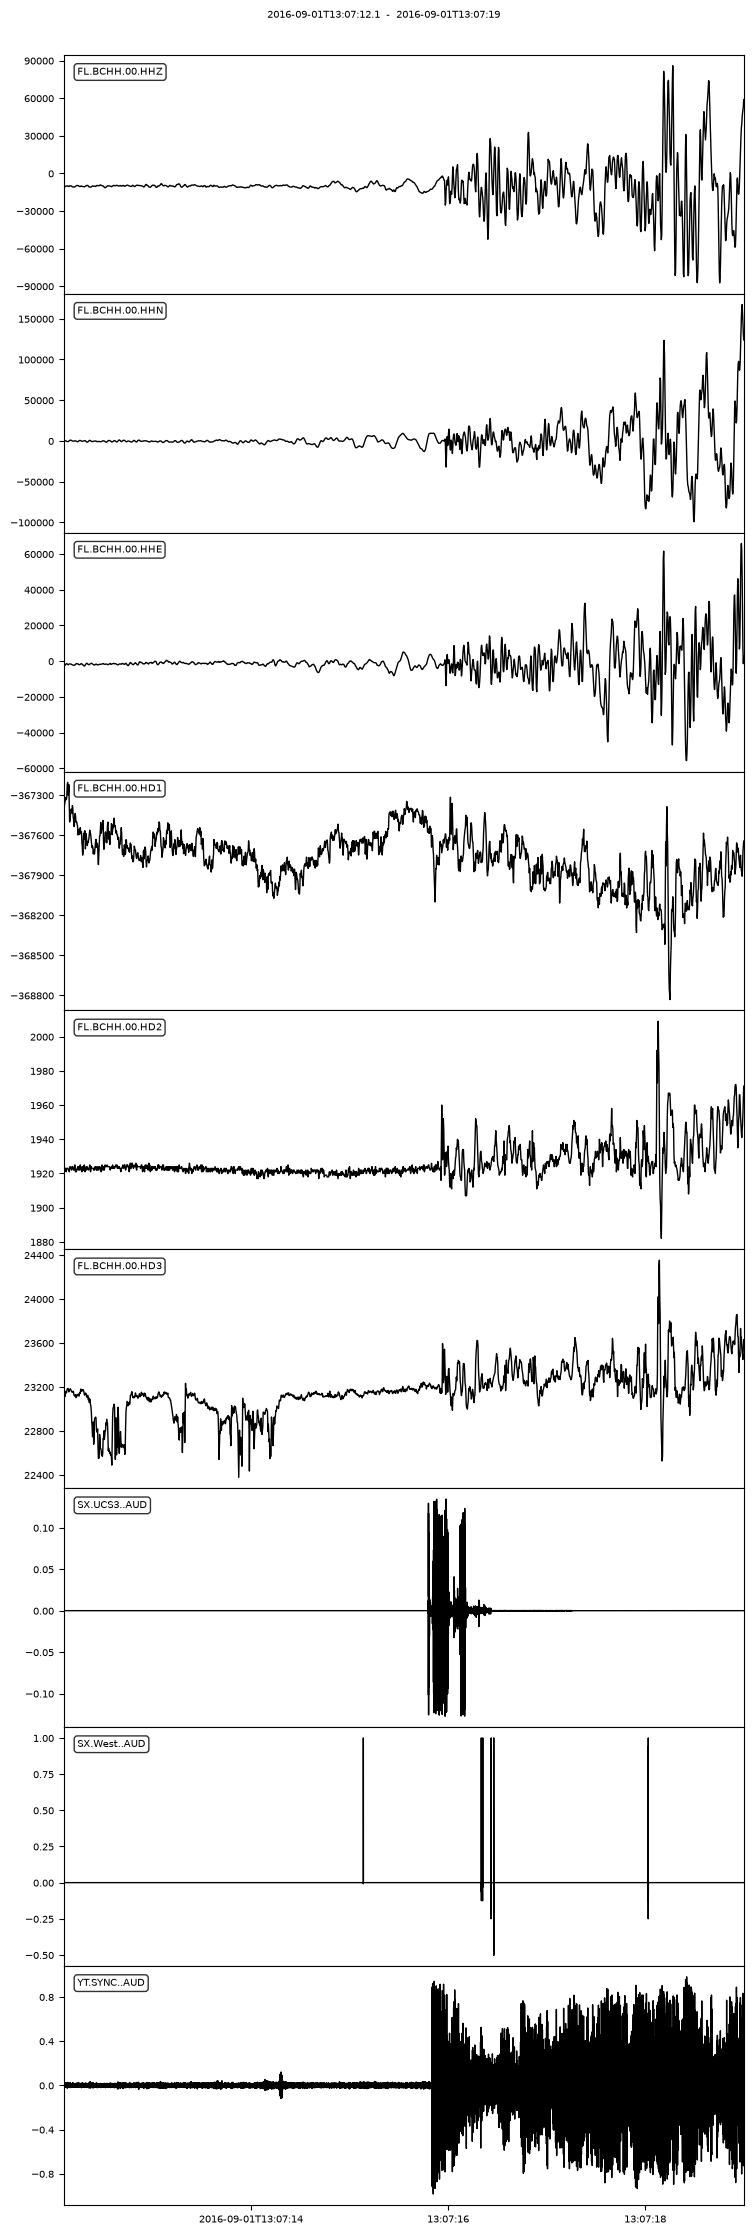

In [ ]:
print(st_ordered)
(st_raw+st_ucs3_raw+st_audio_raw+st_wf_raw).plot(starttime=UTCDateTime(2016,9,1,13,7,12.1), endtime=UTCDateTime(2016,9,1,13,7,19), equal_scale=False);

## 11. Zoom-figure utilities

The same function can make either:

- **Observed-time plot**: traces remain in UTC; dashed arrival ticks show expected acoustic arrivals.
- **Reduced-time plot**: traces are shifted earlier by travel time; source-time red lines should align with arrivals if the assumed propagation speed and source picks are correct.


## 12. Build the zoom stream and figure

Set `REDUCE_TIME=False` to inspect observed UTC arrival times. Set `REDUCE_TIME=True` to shift traces into source time using the effective acoustic speed computed above.


In [ ]:
def build_zoom_stream(
    stcentaur: Stream,
    staudio: Stream,
    zoom_start: UTCDateTime,
    zoom_end: UTCDateTime,
    zerophase: bool,
    infra_freqmin: float = 0.05,
    infra_freqmax: float = 120.0,
    seis_freqmin: float = 0.05,
    seis_freqmax: float = 120.0,
    audio_freqmin: float = 1000.0,
    audio_freqmax: float = 2000.0,
    corners: int = 4,
    pad_seconds: float = 10.0,
) -> Stream:
    """Build the filtered zoom stream, including audio, for one zerophase setting."""
    zoom_infra_filter = bandpass_filter_dict(
        freqmin=infra_freqmin,
        freqmax=infra_freqmax,
        corners=corners,
        zerophase=zerophase,
    )
    zoom_seis_filter = bandpass_filter_dict(
        freqmin=seis_freqmin,
        freqmax=seis_freqmax,
        corners=corners,
        zerophase=zerophase,
    )

    # Rebuild zoom data from response-corrected traces, not from the already filtered overview stream.
    st_zoom_local = preprocess_display_stream(
        stcentaur,
        starttime=zoom_start - pad_seconds,
        endtime=zoom_end + pad_seconds,
        infra_filter=zoom_infra_filter,
        seis_filter=zoom_seis_filter,
    )

    # Audio stays in its own clock convention here. Reduced-time shifting handles
    # audio_delay_s later in one place.
    st_audio_zoom_local = prepare_audio_for_plot(
        staudio,
        zoom_start=zoom_start - pad_seconds,
        zoom_end=zoom_end + pad_seconds,
        freqmin=audio_freqmin,
        freqmax=audio_freqmax,
        normalize=True,
        zerophase=zerophase,
        corners=corners,
    )

    return st_audio_zoom_local + st_zoom_local


def channel_delay_s(
    channel: str,
    sensor_distances_m: dict,
    acoustic_speed_mps: float,
    audio_delay_s: float,
) -> float:
    """
    Return propagation delay for one plotted channel.

    For BCHH we assume both infrasound and HH seismic channels record
    the ground-coupled airwave, so all physical BCHH channels use the
    acoustic travel time.

    Audio is treated separately because it may already be synchronized
    to video/source time, or may have a separate manual clock offset.
    """
    ch = channel.upper()

    if is_audio_channel(ch):
        return audio_delay_s

    if ch in sensor_distances_m:
        return sensor_distances_m[ch] / acoustic_speed_mps

    return 0.0


def reduce_stream_to_source_time_for_zoom(
    st: Stream,
    sensor_distances_m: dict,
    acoustic_speed_mps: float,
    audio_delay_s: float,
) -> Stream:
    """
    Shift traces from observed UTC into reduced/source time.

    After this correction, an airwave travelling at acoustic_speed_mps
    should align with the source event time.
    """
    st_red = st.copy()

    for tr in st_red:
        delay = channel_delay_s(
            channel=tr.stats.channel,
            sensor_distances_m=sensor_distances_m,
            acoustic_speed_mps=acoustic_speed_mps,
            audio_delay_s=audio_delay_s,
        )

        print(f"Reducing {tr.id} by {delay:.4f} s")
        tr.stats.starttime -= delay

    return st_red


def make_zoom_figure_simple(
    st: Stream,
    outfile_base: Path,
    zoom_start: UTCDateTime,
    zoom_end: UTCDateTime,
    source_events: dict,
    sensor_distances_m: dict,
    acoustic_speed_mps: float,
    audio_delay_s: float,
    event_window_s: float,
    reduced_time: bool = False,
    show_source_times: bool = True,
    show_predicted_arrivals: bool = True,
    show_event_windows: bool = False,
    normalize_by_group: bool = False,
    clip: float = 4.0,
    trace_gain: float = 0.18,
):
    """
    Plot BCHH zoom figure.

    Timing convention
    -----------------
    If reduced_time is False:
        traces are shown in observed UTC.
        predicted arrivals are plotted at source_time + travel_time.

    If reduced_time is True:
        traces have already had travel times removed.
        source times are plotted directly.
    """
    if len(st) == 0:
        raise ValueError("No traces to plot")

    fig, ax = plt.subplots(figsize=(11.0, 5.2))

    offsets = np.arange(len(st))[::-1].astype(float)
    channel_labels = []
    channel_y = {}

    infra_scales = [
        robust_scale(tr.data, percentile=99.5)
        for tr in st
        if is_infrasound_channel(tr.stats.channel)
    ]
    seis_scales = [
        robust_scale(tr.data, percentile=99.5)
        for tr in st
        if is_seismic_channel(tr.stats.channel)
    ]

    group_scale_infra = np.median(infra_scales) if infra_scales else 1.0
    group_scale_seis = np.median(seis_scales) if seis_scales else 1.0

    for i, tr in enumerate(st):
        y0 = offsets[i]
        ch = tr.stats.channel.upper()
        channel_y[ch] = y0

        trc = tr.copy().trim(zoom_start, zoom_end, pad=True, fill_value=0)

        t = trace_time_array_datetime64(trc)
        data = np.nan_to_num(
            trc.data.astype(float),
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        )

        if normalize_by_group:
            if is_audio_channel(ch):
                scale = robust_scale(data, percentile=99.5)
            elif is_infrasound_channel(ch):
                scale = group_scale_infra
            else:
                scale = group_scale_seis
        else:
            scale = robust_scale(data, percentile=99.5)

        if scale <= 0 or not np.isfinite(scale):
            scale = 1.0

        y = y0 + np.clip(data / scale, -clip, clip) * trace_gain
        ax.plot(t, y, "-", color="black", lw=0.55, rasterized=True, zorder=12)

        if is_audio_channel(ch):
            channel_labels.append("Audio\n1–2 kHz")
        else:
            channel_labels.append(ch)

    ax.set_yticks(offsets)
    ax.set_yticklabels(channel_labels)
    ax.set_ylim(-0.7, len(st) - 0.25)
    ax.set_xlim(
        mdates.date2num(zoom_start.datetime),
        mdates.date2num(zoom_end.datetime),
    )

    ax.xaxis.set_major_locator(mdates.SecondLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
    ax.xaxis.set_minor_locator(mdates.SecondLocator(interval=1))

    ax.grid(axis="x", which="major", color="0.78", lw=0.8, zorder=1)
    ax.grid(axis="x", which="minor", color="0.93", lw=0.4, zorder=1)
    ax.set_xlabel("Time on 1 September 2016 (UTC)")

    if len(st) >= 6:
        ax.axhline(2.5, color="0.55", lw=0.8, zorder=10)

    def draw_short_vline(x, y0, half_height=0.38, **kwargs):
        ax.vlines(x, y0 - half_height, y0 + half_height, **kwargs)

    ytop = len(st) - 0.15

    for label, source_time in source_events.items():

        if show_source_times and zoom_start <= source_time <= zoom_end:
            x = mdates.date2num(source_time.datetime)

            ax.axvline(
                x,
                color="firebrick",
                lw=1.1,
                alpha=0.85,
                zorder=25,
            )

            ax.text(
                x,
                ytop,
                label,
                rotation=90,
                ha="center",
                va="top",
                fontsize=8,
                color="firebrick",
                alpha=0.90,
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.75,
                    pad=1.0,
                ),
                clip_on=False,
                zorder=30,
            )

        for ch, y0 in channel_y.items():

            if reduced_time:
                arrival_time = source_time
            else:
                delay = channel_delay_s(
                    channel=ch,
                    sensor_distances_m=sensor_distances_m,
                    acoustic_speed_mps=acoustic_speed_mps,
                    audio_delay_s=audio_delay_s,
                )
                arrival_time = source_time + delay

            if show_event_windows:
                t_left = arrival_time - event_window_s / 2
                t_right = arrival_time + event_window_s / 2

                if t_right >= zoom_start and t_left <= zoom_end:
                    ax.fill_betweenx(
                        [y0 - 0.42, y0 + 0.42],
                        mdates.date2num(max(t_left, zoom_start).datetime),
                        mdates.date2num(min(t_right, zoom_end).datetime),
                        color="0.75",
                        alpha=0.35,
                        lw=0,
                        zorder=18,
                    )

            if show_predicted_arrivals and zoom_start <= arrival_time <= zoom_end:
                x = mdates.date2num(arrival_time.datetime)

                color = "firebrick" if is_infrasound_channel(ch) else "0.25"

                draw_short_vline(
                    x,
                    y0,
                    color=color,
                    lw=0.9,
                    linestyles="--",
                    alpha=0.6,
                    zorder=22,
                )

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    fig.subplots_adjust(left=0.08, right=0.99, top=0.96, bottom=0.15)

    for ext in ["png", "pdf"]:
        fig.savefig(
            outfile_base.with_suffix(f".{ext}"),
            dpi=300,
            bbox_inches="tight",
            pad_inches=0.04,
        )

    return fig, ax


def make_zoom_variant(
    stcentaur: Stream,
    staudio: Stream,
    output_dir: Path,
    zerophase: bool,
    reduce_time: bool,
    window_start: UTCDateTime,
    window_end: UTCDateTime,
    source_events: dict,
    sensor_distances_m: dict,
    acoustic_speed_mps: float,
    audio_delay_s: float,
    event_window_s: float,
    outfile_stem: str = "fig03_bchh_20s_zoom_with_audio",
    show: bool = True,
    zoom_filter_settings: dict | None = None,
    plot_settings: dict | None = None,
):
    """Build and plot one zoom figure for a zerophase/reduced-time combination.

    All quantities that affect the result are arguments rather than hidden globals.
    """
    if zoom_filter_settings is None:
        zoom_filter_settings = {}
    if plot_settings is None:
        plot_settings = {}

    st_zoom_local = build_zoom_stream(
        stcentaur=stcentaur,
        staudio=staudio,
        zoom_start=window_start,
        zoom_end=window_end,
        zerophase=zerophase,
        **zoom_filter_settings,
    )

    if reduce_time:
        st_zoom_plot_local = reduce_stream_to_source_time_for_zoom(
            st=st_zoom_local,
            sensor_distances_m=sensor_distances_m,
            acoustic_speed_mps=acoustic_speed_mps,
            audio_delay_s=audio_delay_s,
        )
        timing_tag = "reduced"
    else:
        st_zoom_plot_local = st_zoom_local.copy()
        timing_tag = "observed"

    st_zoom_plot_local.trim(window_start, window_end, pad=False)

    outfile_local = output_dir / f"{outfile_stem}_{timing_tag}_{zerophase_tag(zerophase)}"

    print(
        f"Plotting {outfile_local.name}: "
        f"ZEROPHASE={zerophase}, REDUCE_TIME={reduce_time}, "
        f"acoustic speed={acoustic_speed_mps:.1f} m/s"
    )

    fig, ax = make_zoom_figure_simple(
        st=st_zoom_plot_local,
        outfile_base=outfile_local,
        zoom_start=window_start,
        zoom_end=window_end,
        source_events=source_events,
        sensor_distances_m=sensor_distances_m,
        acoustic_speed_mps=acoustic_speed_mps,
        audio_delay_s=audio_delay_s,
        event_window_s=event_window_s,
        reduced_time=reduce_time,
        show_source_times=plot_settings.get("show_source_times", True),
        show_predicted_arrivals=plot_settings.get("show_predicted_arrivals", not reduce_time),
        show_event_windows=plot_settings.get("show_event_windows", False),
        normalize_by_group=plot_settings.get("normalize_by_group", False),
        clip=plot_settings.get("clip", 1.2),
        trace_gain=plot_settings.get("trace_gain", 0.4),
    )

    if show:
        plt.show()
    else:
        plt.close(fig)

    return {
        "zerophase": zerophase,
        "reduce_time": reduce_time,
        "stream": st_zoom_plot_local,
        "outfile": outfile_local,
        "fig": fig,
        "ax": ax,
    }



Acoustic speed = 348.6 m/s
Wind speed = 5.1 m/s
Effective acoustic speed = 348.6 m/s
Adding a time adjustment of 0.20 s to align Centaur data to SpaceX video event time markers
Adjusted speed from 348.6 m/s to 366.6 m/s to match the time adjustment
Audio is delayed by 3.75 s
Reducing YT.SYNC..AUD by 3.7550 s
Reducing FL.BCHH.00.HD1 by 3.9340 s
Reducing FL.BCHH.00.HD2 by 3.8467 s
Reducing FL.BCHH.00.HD3 by 3.8593 s
Reducing FL.BCHH.00.HHE by 3.8784 s
Reducing FL.BCHH.00.HHN by 3.8784 s
Reducing FL.BCHH.00.HHZ by 3.8784 s
Plotting fig03_bchh_20s_zoom_with_audio_reduced_zp_false: ZEROPHASE=False, REDUCE_TIME=True, acoustic speed=366.6 m/s


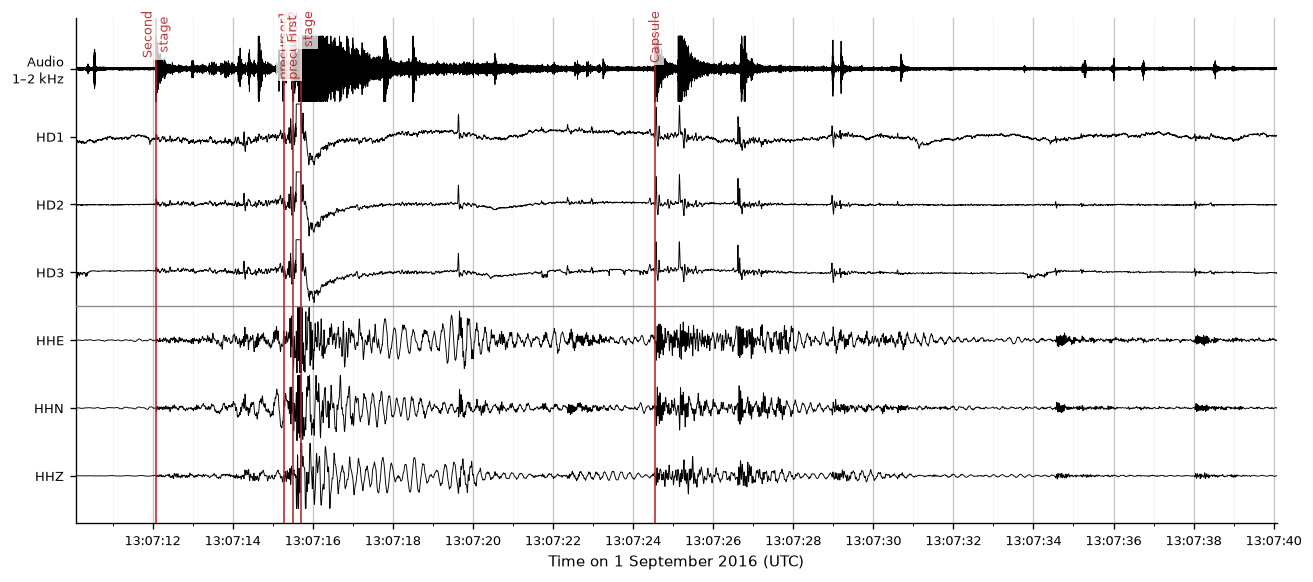

Reducing YT.SYNC..AUD by 3.7550 s
Reducing FL.BCHH.00.HD1 by 3.9340 s
Reducing FL.BCHH.00.HD2 by 3.8467 s
Reducing FL.BCHH.00.HD3 by 3.8593 s
Reducing FL.BCHH.00.HHE by 3.8784 s
Reducing FL.BCHH.00.HHN by 3.8784 s
Reducing FL.BCHH.00.HHZ by 3.8784 s
Plotting fig03_bchh_20s_zoom_with_audio_reduced_zp_true: ZEROPHASE=True, REDUCE_TIME=True, acoustic speed=366.6 m/s


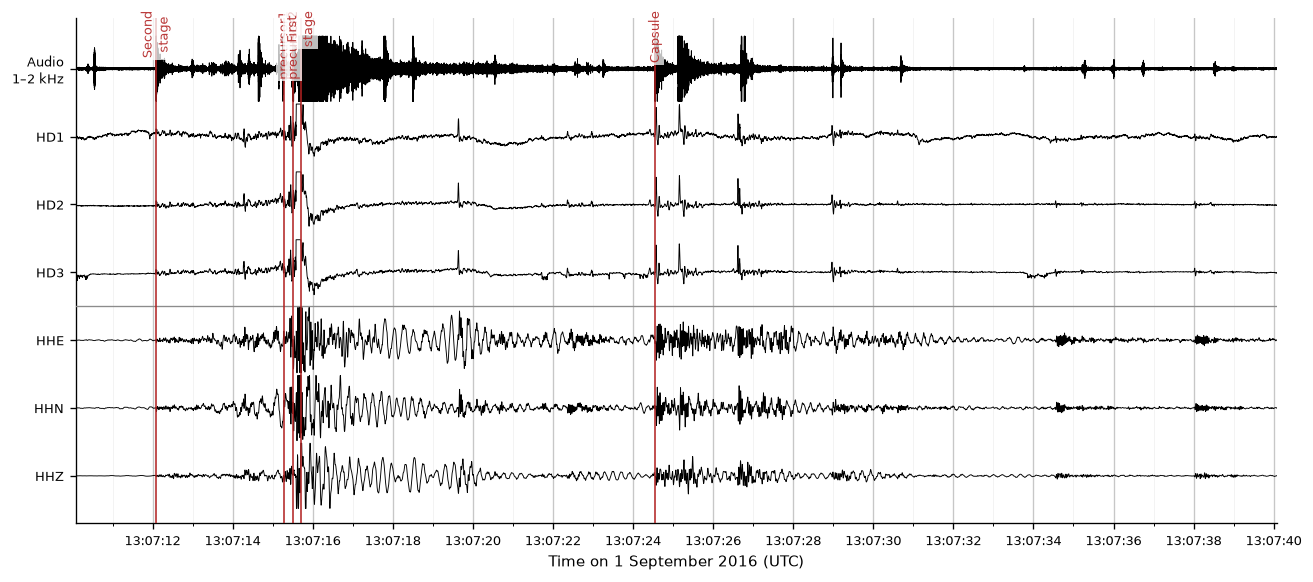

Reducing YT.SYNC..AUD by 3.7550 s
Reducing FL.BCHH.00.HD1 by 3.9340 s
Reducing FL.BCHH.00.HD2 by 3.8467 s
Reducing FL.BCHH.00.HD3 by 3.8593 s
Reducing FL.BCHH.00.HHE by 3.8784 s
Reducing FL.BCHH.00.HHN by 3.8784 s
Reducing FL.BCHH.00.HHZ by 3.8784 s
Plotting fig03_bchh_first_stage_closeup_with_audio_reduced_zp_false: ZEROPHASE=False, REDUCE_TIME=True, acoustic speed=366.6 m/s


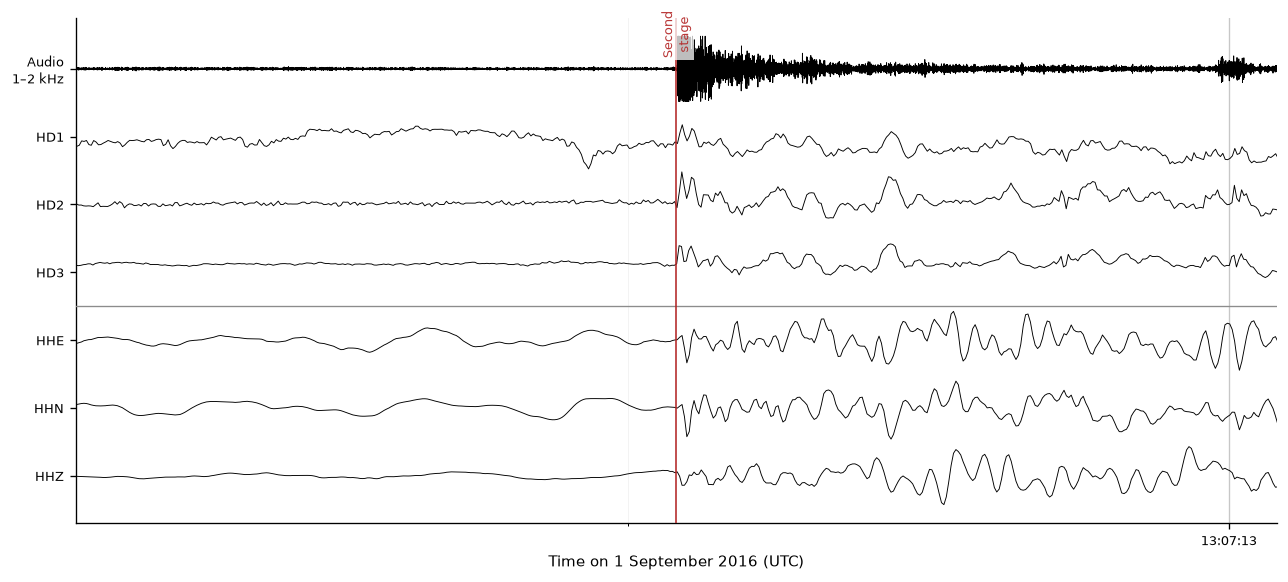

Reducing YT.SYNC..AUD by 3.7550 s
Reducing FL.BCHH.00.HD1 by 3.9340 s
Reducing FL.BCHH.00.HD2 by 3.8467 s
Reducing FL.BCHH.00.HD3 by 3.8593 s
Reducing FL.BCHH.00.HHE by 3.8784 s
Reducing FL.BCHH.00.HHN by 3.8784 s
Reducing FL.BCHH.00.HHZ by 3.8784 s
Plotting fig03_bchh_first_stage_closeup_with_audio_reduced_zp_true: ZEROPHASE=True, REDUCE_TIME=True, acoustic speed=366.6 m/s


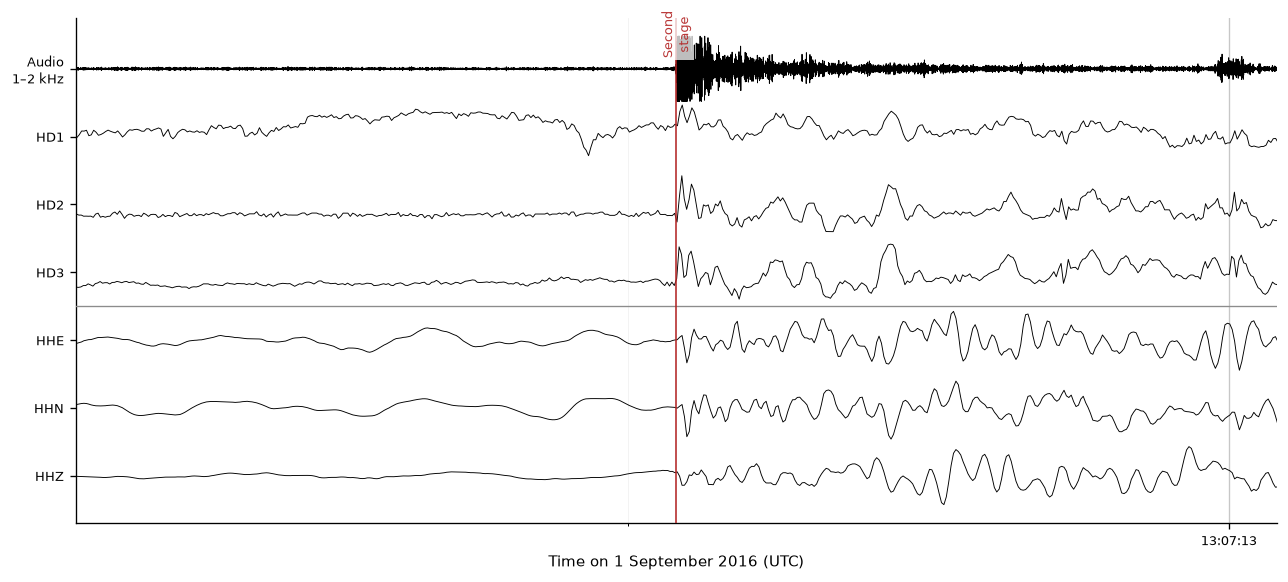

Reducing YT.SYNC..AUD by 3.7550 s
Reducing FL.BCHH.00.HD1 by 3.9340 s
Reducing FL.BCHH.00.HD2 by 3.8467 s
Reducing FL.BCHH.00.HD3 by 3.8593 s
Reducing FL.BCHH.00.HHE by 3.8784 s
Reducing FL.BCHH.00.HHN by 3.8784 s
Reducing FL.BCHH.00.HHZ by 3.8784 s
Plotting fig03_bchh_first_stage_closeup_with_audio_reduced_zp_false: ZEROPHASE=False, REDUCE_TIME=True, acoustic speed=366.6 m/s


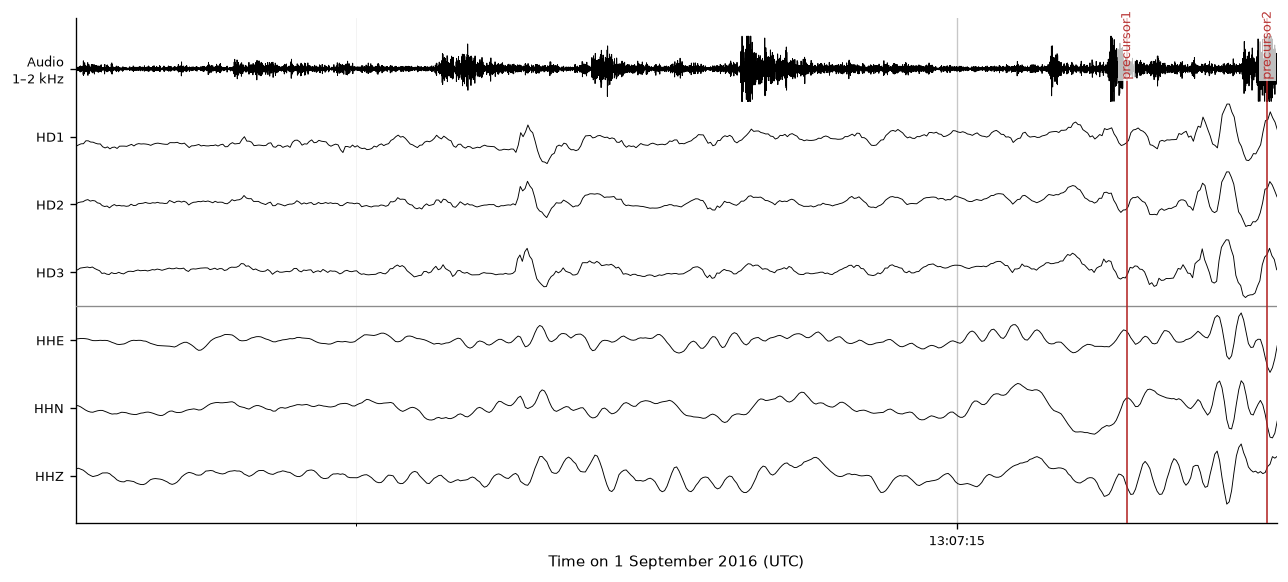

Reducing YT.SYNC..AUD by 3.7550 s
Reducing FL.BCHH.00.HD1 by 3.9340 s
Reducing FL.BCHH.00.HD2 by 3.8467 s
Reducing FL.BCHH.00.HD3 by 3.8593 s
Reducing FL.BCHH.00.HHE by 3.8784 s
Reducing FL.BCHH.00.HHN by 3.8784 s
Reducing FL.BCHH.00.HHZ by 3.8784 s
Plotting fig03_bchh_first_stage_closeup_with_audio_reduced_zp_true: ZEROPHASE=True, REDUCE_TIME=True, acoustic speed=366.6 m/s


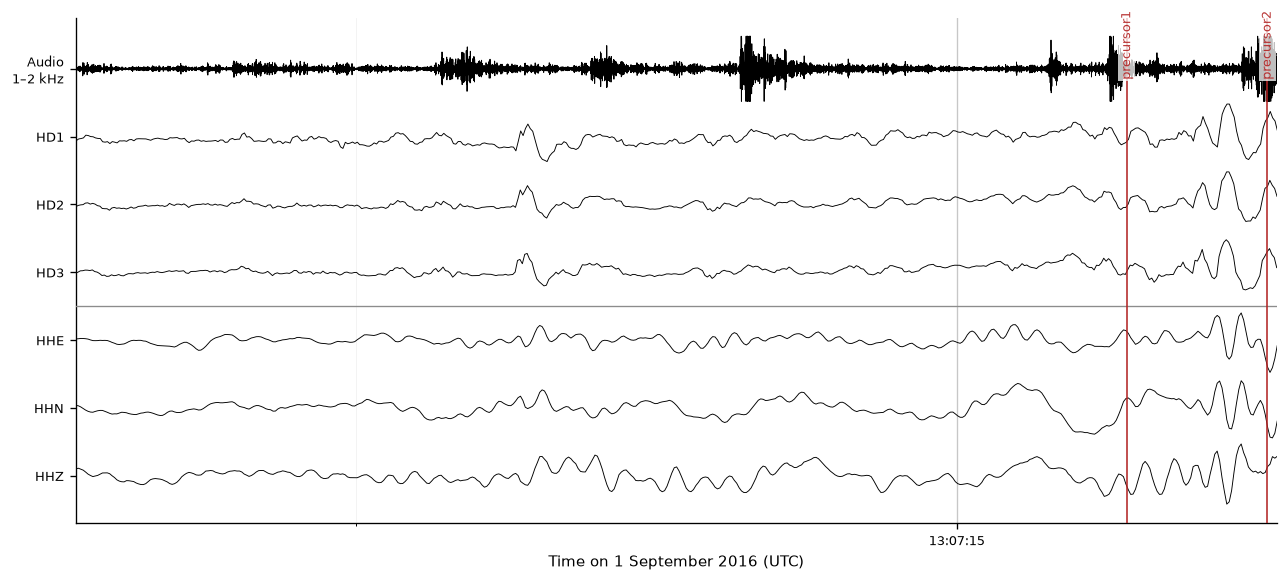

Reducing YT.SYNC..AUD by 3.7550 s
Reducing FL.BCHH.00.HD1 by 3.9340 s
Reducing FL.BCHH.00.HD2 by 3.8467 s
Reducing FL.BCHH.00.HD3 by 3.8593 s
Reducing FL.BCHH.00.HHE by 3.8784 s
Reducing FL.BCHH.00.HHN by 3.8784 s
Reducing FL.BCHH.00.HHZ by 3.8784 s
Plotting fig03_bchh_first_stage_closeup_with_audio_reduced_zp_false: ZEROPHASE=False, REDUCE_TIME=True, acoustic speed=366.6 m/s


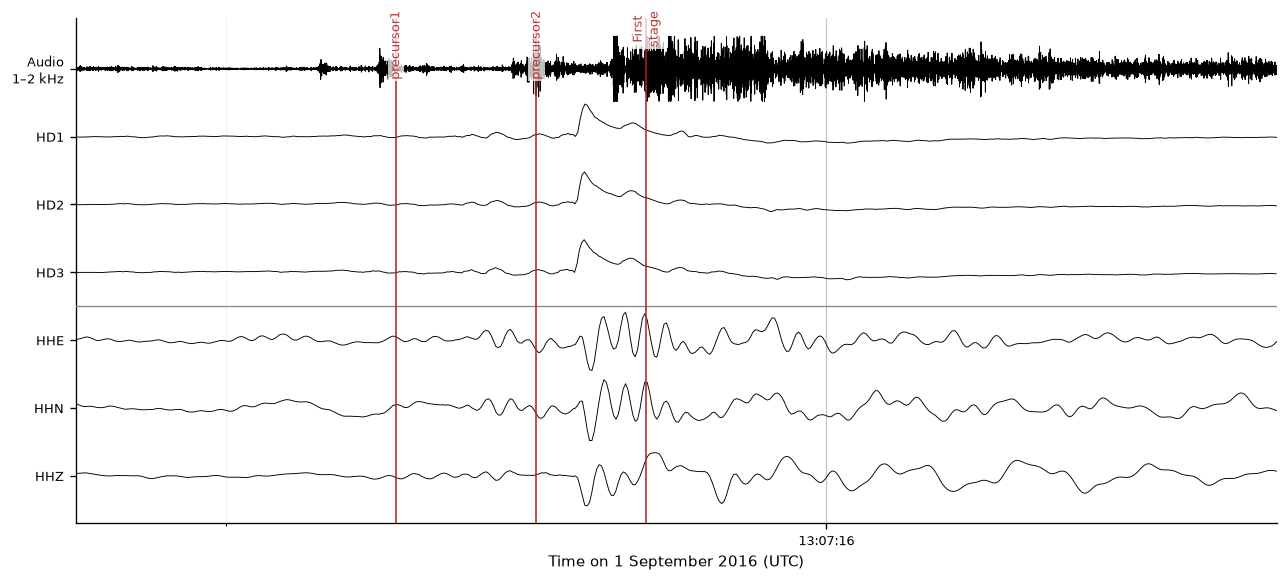

Reducing YT.SYNC..AUD by 3.7550 s
Reducing FL.BCHH.00.HD1 by 3.9340 s
Reducing FL.BCHH.00.HD2 by 3.8467 s
Reducing FL.BCHH.00.HD3 by 3.8593 s
Reducing FL.BCHH.00.HHE by 3.8784 s
Reducing FL.BCHH.00.HHN by 3.8784 s
Reducing FL.BCHH.00.HHZ by 3.8784 s
Plotting fig03_bchh_first_stage_closeup_with_audio_reduced_zp_true: ZEROPHASE=True, REDUCE_TIME=True, acoustic speed=366.6 m/s


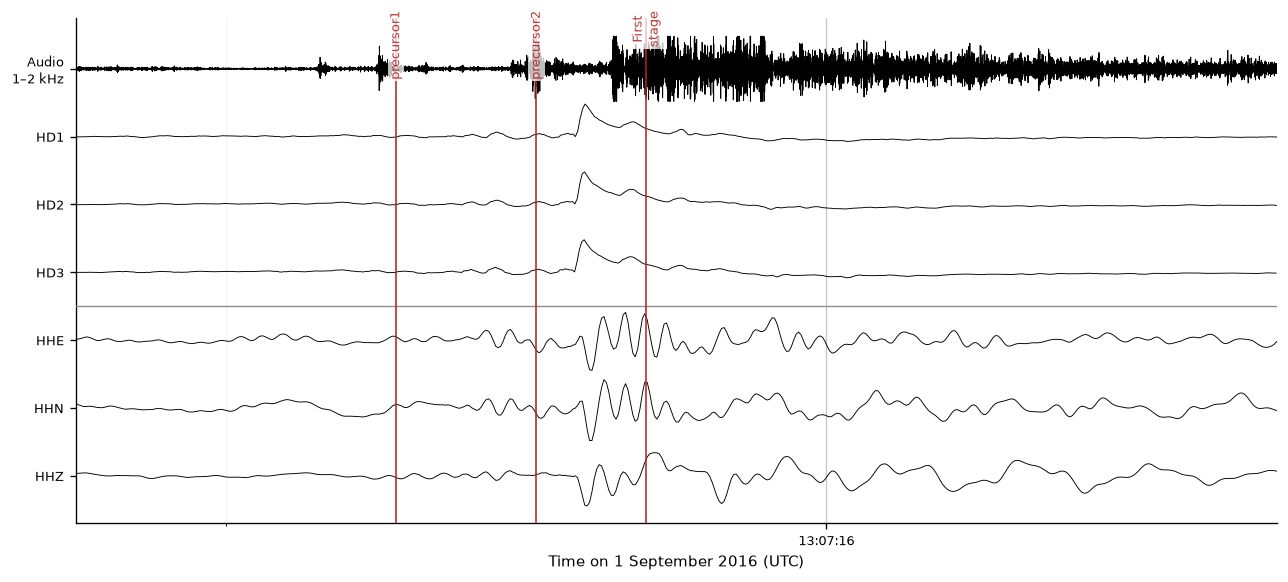

Reducing YT.SYNC..AUD by 3.7550 s
Reducing FL.BCHH.00.HD1 by 3.9340 s
Reducing FL.BCHH.00.HD2 by 3.8467 s
Reducing FL.BCHH.00.HD3 by 3.8593 s
Reducing FL.BCHH.00.HHE by 3.8784 s
Reducing FL.BCHH.00.HHN by 3.8784 s
Reducing FL.BCHH.00.HHZ by 3.8784 s
Plotting fig03_bchh_first_stage_closeup_with_audio_reduced_zp_false: ZEROPHASE=False, REDUCE_TIME=True, acoustic speed=366.6 m/s


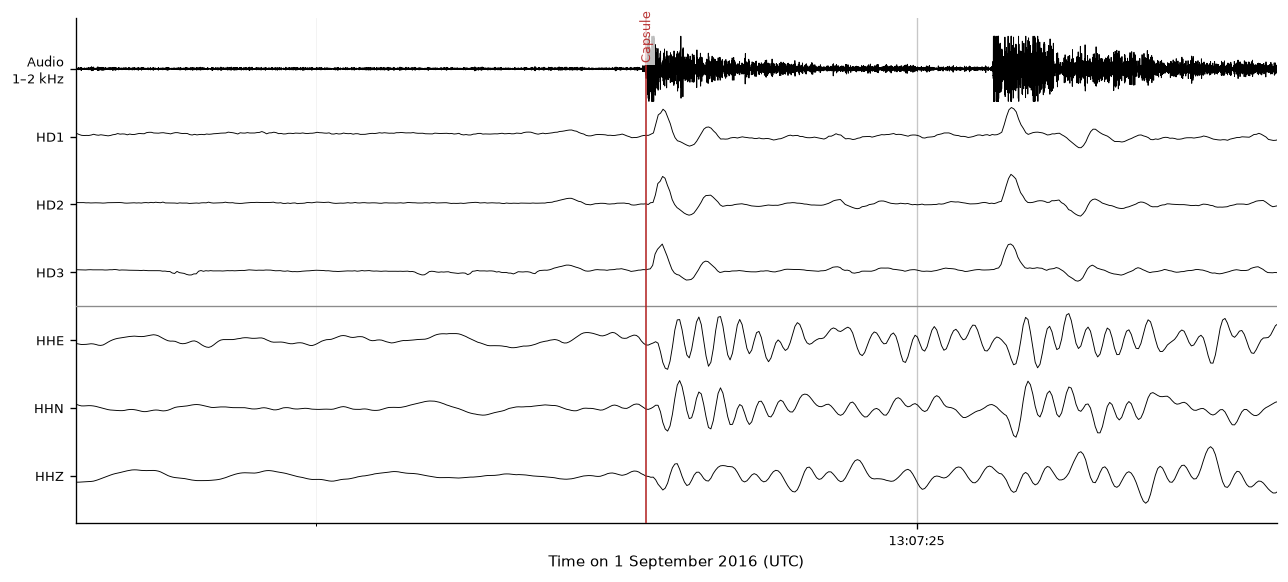

Reducing YT.SYNC..AUD by 3.7550 s
Reducing FL.BCHH.00.HD1 by 3.9340 s
Reducing FL.BCHH.00.HD2 by 3.8467 s
Reducing FL.BCHH.00.HD3 by 3.8593 s
Reducing FL.BCHH.00.HHE by 3.8784 s
Reducing FL.BCHH.00.HHN by 3.8784 s
Reducing FL.BCHH.00.HHZ by 3.8784 s
Plotting fig03_bchh_first_stage_closeup_with_audio_reduced_zp_true: ZEROPHASE=True, REDUCE_TIME=True, acoustic speed=366.6 m/s


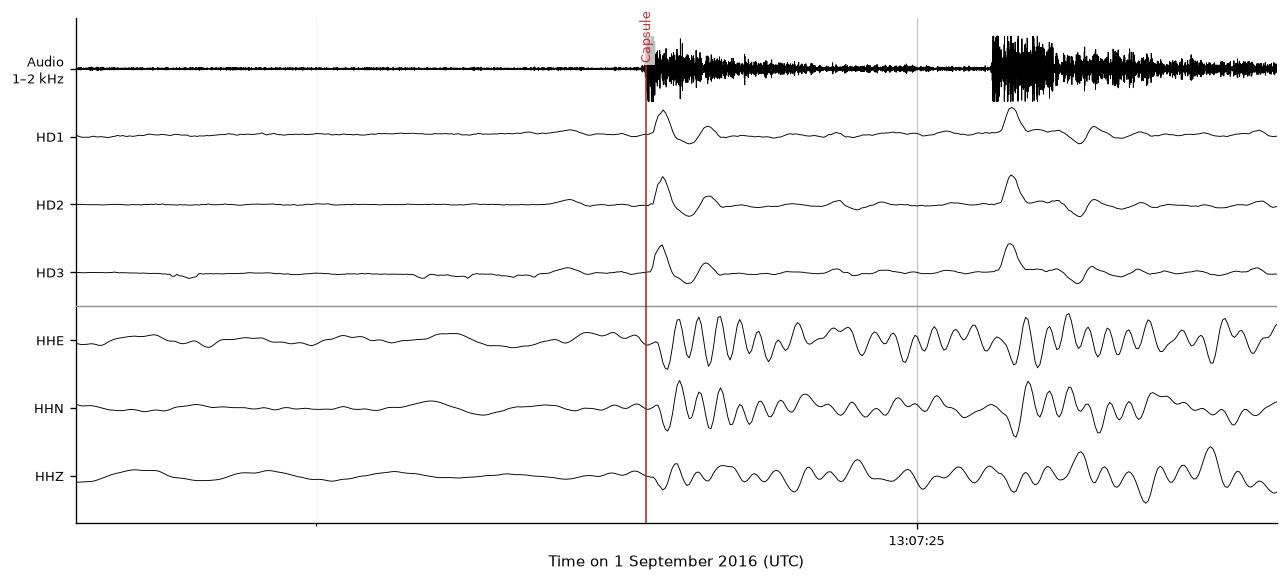

In [ ]:

REDUCE_TIME = True

zoom_start = EXPLOSION_TIME - 2
zoom_end = EXPLOSION_TIME + 28
# effective acoustic speed is 353.8 m/s

# If the audio trace start time has already been synchronized to source/video time,
# keep this at 0. If the audio is still in observed time, set the needed shift here.

# best numbers for acoustic arrivals
audio_delay_s = 3.89
time_tweak = 0.12 #+ 0.15
audio_tweak = 0.0
# corresponds to 363.7 m/s
# but we should adjust the centaur data and audio by these amounts - and then do the additional processing

# best numbers for big blast arrivals
'''
audio_delay_s = 3.89
time_tweak = 0.29
audio_tweak = 0.065
'''
# corresponds to 381.3 m/s


# best numbers for acoustic arrivals
audio_delay_s = 3.955
time_tweak = 0.2
audio_tweak = 0.0
# corresponds to 
# but we should adjust the centaur data and audio by these amounts - and then do the additional processing

# best numbers for big blast arrivals
'''
audio_delay_s = 3.89
time_tweak = 0.29
audio_tweak = 0.065
'''
# corresponds to 

SOURCE_EVENTS['First\nstage'] = UTCDateTime(2016, 9, 1, 13, 7, 15.7)
SOURCE_EVENTS['Capsule'] = UTCDateTime(2016, 9, 1, 13, 7, 24.55) 

seismic_distance = SENSOR_DISTANCES_M["HHZ"]
EFFECTIVE_ACOUSTIC_SPEED_MPS = ACOUSTIC_SPEED_MPS# + WIND_SPEED_MPS

print(f"Acoustic speed = {ACOUSTIC_SPEED_MPS:.1f} m/s")
print(f"Wind speed = {WIND_SPEED_MPS:.1f} m/s")
print(f"Effective acoustic speed = {EFFECTIVE_ACOUSTIC_SPEED_MPS:.1f} m/s")
print(f"Adding a time adjustment of {time_tweak:.2f} s to align Centaur data to SpaceX video event time markers")

speed_to_use = seismic_distance / (seismic_distance / EFFECTIVE_ACOUSTIC_SPEED_MPS - time_tweak)
audio_delay_to_use = audio_delay_s - time_tweak + audio_tweak

print(f"Adjusted speed from {EFFECTIVE_ACOUSTIC_SPEED_MPS:.1f} m/s to {speed_to_use:.1f} m/s to match the time adjustment")
print(f"Audio is delayed by {audio_delay_to_use:.2f} s")

zoom_filter_settings = {
    "infra_freqmin": 0.05,
    "infra_freqmax": 120.0,
    "seis_freqmin": 0.05,
    "seis_freqmax": 120.0,
    "audio_freqmin": 1000.0,
    "audio_freqmax": 2000.0,
    "corners": 4,
    "pad_seconds": 10.0,
}

zoom_plot_settings = {
    "show_source_times": True,
    "show_event_windows": False,
    "normalize_by_group": False,
    "clip": 1.2,
    "trace_gain": 0.4,
}

zoom_results = []
zerophase_values_to_run = ZEROPHASE_RUNS if RUN_ZEROPHASE_COMPARISON else [ZEROPHASE]

for zp in zerophase_values_to_run:
    zoom_results.append(
        make_zoom_variant(
            stcentaur=st_ordered,
            staudio=st_audio_raw,
            output_dir=OUTDIR,
            zerophase=zp,
            reduce_time=REDUCE_TIME,
            window_start=zoom_start,
            window_end=zoom_end,
            source_events=SOURCE_EVENTS,
            sensor_distances_m=SENSOR_DISTANCES_M,
            acoustic_speed_mps=speed_to_use,
            audio_delay_s=audio_delay_to_use,
            event_window_s=VIDEO_PICK_UNCERTAINTY_S,
            outfile_stem="fig03_bchh_20s_zoom_with_audio",
            show=True,
            zoom_filter_settings=zoom_filter_settings,
            plot_settings=zoom_plot_settings,
        )
    )

# Backward-compatible names for later exploratory cells.
st_zoom_plot = zoom_results[0]["stream"]
outfile = zoom_results[0]["outfile"]

# Optional tighter view around the first-stage event for every zerophase variant.
closeup_results = []

for result in zoom_results:
    closeup_results.append(
        make_zoom_variant(
            stcentaur=st_ordered,
            staudio=st_audio_raw,
            output_dir=OUTDIR,
            zerophase=result["zerophase"],
            reduce_time=result["reduce_time"],
            window_start=EXPLOSION_TIME - 1,
            window_end=EXPLOSION_TIME + 1,
            source_events=SOURCE_EVENTS,
            sensor_distances_m=SENSOR_DISTANCES_M,
            acoustic_speed_mps=speed_to_use,
            audio_delay_s=audio_delay_to_use,
            event_window_s=VIDEO_PICK_UNCERTAINTY_S,
            outfile_stem="fig03_bchh_first_stage_closeup_with_audio",
            show=True,
            zoom_filter_settings=zoom_filter_settings,
            plot_settings=zoom_plot_settings,
        )
    )

for result in zoom_results:
    closeup_results.append(
        make_zoom_variant(
            stcentaur=st_ordered,
            staudio=st_audio_raw,
            output_dir=OUTDIR,
            zerophase=result["zerophase"],
            reduce_time=result["reduce_time"],
            window_start=precursor1 - 1.75,
            window_end=precursor1 + 0.25,
            source_events=SOURCE_EVENTS,
            sensor_distances_m=SENSOR_DISTANCES_M,
            acoustic_speed_mps=speed_to_use,
            audio_delay_s=audio_delay_to_use,
            event_window_s=VIDEO_PICK_UNCERTAINTY_S,
            outfile_stem="fig03_bchh_first_stage_closeup_with_audio",
            show=True,
            zoom_filter_settings=zoom_filter_settings,
            plot_settings=zoom_plot_settings,
        )
    )

for result in zoom_results:
    closeup_results.append(
        make_zoom_variant(
            stcentaur=st_ordered,
            staudio=st_audio_raw,
            output_dir=OUTDIR,
            zerophase=result["zerophase"],
            reduce_time=result["reduce_time"],
            window_start=FIRST_STAGE - 1,
            window_end=FIRST_STAGE + 1,
            source_events=SOURCE_EVENTS,
            sensor_distances_m=SENSOR_DISTANCES_M,
            acoustic_speed_mps=speed_to_use,
            audio_delay_s=audio_delay_to_use,
            event_window_s=VIDEO_PICK_UNCERTAINTY_S,
            outfile_stem="fig03_bchh_first_stage_closeup_with_audio",
            show=True,
            zoom_filter_settings=zoom_filter_settings,
            plot_settings=zoom_plot_settings,
        )
    )


for result in zoom_results:
    closeup_results.append(
        make_zoom_variant(
            stcentaur=st_ordered,
            staudio=st_audio_raw,
            output_dir=OUTDIR,
            zerophase=result["zerophase"],
            reduce_time=result["reduce_time"],
            window_start=CAPSULE - 1,
            window_end=CAPSULE + 1,
            source_events=SOURCE_EVENTS,
            sensor_distances_m=SENSOR_DISTANCES_M,
            acoustic_speed_mps=speed_to_use,
            audio_delay_s=audio_delay_to_use,
            event_window_s=VIDEO_PICK_UNCERTAINTY_S,
            outfile_stem="fig03_bchh_first_stage_closeup_with_audio",
            show=True,
            zoom_filter_settings=zoom_filter_settings,
            plot_settings=zoom_plot_settings,
        )
    )




## 13. Timing residual worksheet

Fill in observed pick times for one or more channels/events to see whether the residual is constant, event-dependent, or channel-dependent.


In [ ]:
def required_velocity(distance_m, source_time, observed_arrival_time):
    """Velocity required to connect a source time to an observed arrival time."""
    dt = observed_arrival_time - source_time
    return np.nan if dt <= 0 else distance_m / dt


def predicted_arrival_time(
    channel: str,
    source_time: UTCDateTime,
    sensor_distances_m: dict,
    acoustic_speed_mps: float,
    direct_seismic_speed_mps: float,
    hh_use_direct_seismic_speed: bool,
):
    """Predicted arrival time for a channel/event under explicitly supplied timing assumptions."""
    if channel not in sensor_distances_m:
        return source_time

    delay_s = acoustic_or_seismic_delay_s(
        channel=channel,
        distance_m=sensor_distances_m[channel],
        acoustic_speed_mps=acoustic_speed_mps,
        direct_seismic_speed_mps=direct_seismic_speed_mps,
        hh_use_direct_seismic_speed=hh_use_direct_seismic_speed,
    )
    return source_time + delay_s


# Example structure: replace None with observed UTCDateTime picks from the traces.
pick_rows = []
for event_name, source_time in SOURCE_EVENTS.items():
    for ch in CHANNEL_ORDER:
        predicted = predicted_arrival_time(
            channel=ch,
            source_time=source_time,
            sensor_distances_m=SENSOR_DISTANCES_M,
            acoustic_speed_mps=speed_to_use,
            direct_seismic_speed_mps=DIRECT_SEISMIC_SPEED_MPS,
            hh_use_direct_seismic_speed=HH_USE_DIRECT_SEISMIC_SPEED,
        )
        observed = None  # e.g., UTCDateTime('2016-09-01T13:07:15.950')
        residual_s = None if observed is None else observed - predicted
        v_req = None if observed is None else required_velocity(SENSOR_DISTANCES_M[ch], source_time, observed)
        pick_rows.append({
            'event': event_name.replace('\n', ' '),
            'channel': ch,
            'source_time': source_time.isoformat(),
            'predicted_arrival': predicted.isoformat(),
            'observed_arrival': observed,
            'residual_s': residual_s,
            'required_velocity_mps': v_req,
        })

try:
    import pandas as pd
    display(pd.DataFrame(pick_rows))
except Exception:
    for row in pick_rows:
        print(row)


,event,channel,source_time,predicted_arrival,observed_arrival,residual_s,required_velocity_mps
0,Second stage,HD1,2016-09-01T13:07:12.080000,2016-09-01T13:07:16.014022,None,None,None
1,Second stage,HD2,2016-09-01T13:07:12.080000,2016-09-01T13:07:15.926733,None,None,None
2,Second stage,HD3,2016-09-01T13:07:12.080000,2016-09-01T13:07:15.939281,None,None,None
3,Second stage,HHE,2016-09-01T13:07:12.080000,2016-09-01T13:07:12.080000,None,None,None
4,Second stage,HHN,2016-09-01T13:07:12.080000,2016-09-01T13:07:12.080000,None,None,None
5,Second stage,HHZ,2016-09-01T13:07:12.080000,2016-09-01T13:07:12.080000,None,None,None
6,precursor1,HD1,2016-09-01T13:07:15.283000,2016-09-01T13:07:19.217022,None,None,None
7,precursor1,HD2,2016-09-01T13:07:15.283000,2016-09-01T13:07:19.129733,None,None,None
8,precursor1,HD3,2016-09-01T13:07:15.283000,2016-09-01T13:07:19.142281,None,None,None
9,precursor1,HHE,2016-09-01T13:07:15.283000,2016-09-01T13:07:15.283000,None,None,None


## 14. PSD

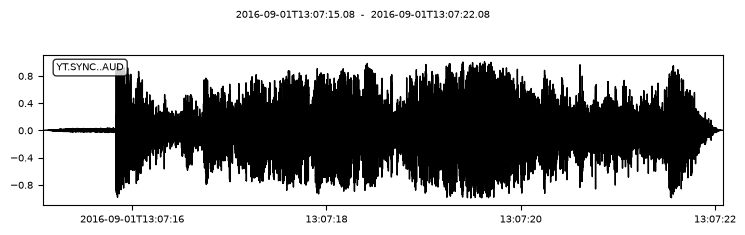

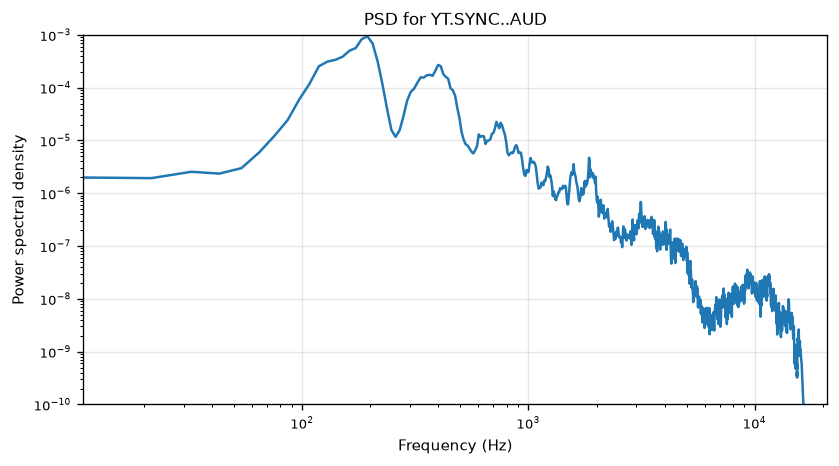

In [ ]:
from scipy.signal import welch
import matplotlib.pyplot as plt
def psd_plot(st, xlims=None, ylims=None, nyquist_percentage=0.95, plot_trace=False):
    for tr in st:
        tr = tr.copy()
        tr.detrend("demean")
        tr.taper(max_percentage=0.05)
        if plot_trace:
            tr.plot()

        fs = tr.stats.sampling_rate
        highest_freq_to_plot = 0.5 * fs * nyquist_percentage
        x = tr.data.astype(float)

        f, Pxx = welch(
            x,
            fs=fs,
            nperseg=min(4096, len(x)),
            noverlap=None,
            scaling="density"
        )

        plt.figure(figsize=(8, 4))
        plt.loglog(f, Pxx)
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Power spectral density")
        plt.title(f"PSD for {tr.id}")
        if xlims is None:
            xlims = (f[1], highest_freq_to_plot)
        xlims = (max(xlims[0], f[1]), min(xlims[1], highest_freq_to_plot))
        plt.xlim(xlims)
        if ylims is not None:
            plt.ylim(ylims)
        plt.grid(True, alpha=0.3)
        plt.show()

st_spec = st_audio_raw.copy().trim(starttime=EXPLOSION_TIME+3, endtime=EXPLOSION_TIME+10)
psd_plot(st_spec, ylims=(1e-10, 1e-3), plot_trace=True)#, xlims=(1, 10000))